<a href="https://colab.research.google.com/github/pulak335/BanglaSpeech2Text/blob/main/ai_cfo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
%%bash
pip install -q pandas numpy scikit-learn lightgbm xgboost prophet langchain langchain-community duckdb openpyxl google-genai

### Imports
Now we will import the installed libraries and set up the Gemini client. To use the Gemini API, make sure to add your API key to Colab's secret manager (the key icon on the left panel) with the name `GOOGLE_API_KEY`.

In [52]:
import pandas as pd
import numpy as np
import duckdb
import openpyxl
import lightgbm as lgb
import xgboost as xgb
from prophet import Prophet

# LangChain imports
from langchain_core.prompts import ChatPromptTemplate

# Google GenAI SDK import
from google import genai
from google.colab import userdata

try:
    # Retrieve API key from Colab Secrets
    api_key = userdata.get('GOOGLE_API_KEY')
    client = genai.Client(api_key=api_key)
    print("Libraries successfully imported, and Gemini Client initialized!")
except Exception as e:
    print(f"Warning: Could not initialize Gemini Client: {e}")
    print("Please ensure you have configured GOOGLE_API_KEY in your Colab Secrets.")

Please ensure you have configured GOOGLE_API_KEY in your Colab Secrets.


### Demonstration of Gemini API
Here is a quick test to query the `gemini-2.5-flash-lite` model.

In [53]:
try:
    response = client.models.generate_content(
        model='gemini-2.5-flash-lite',
        contents='Explain data science in one short sentence.',
    )
    print("Gemini response:", response.text)
except Exception as e:
    print("Unable to run Gemini demo. Please check your API key configuration.", e)

Unable to run Gemini demo. Please check your API key configuration. name 'client' is not defined


In [54]:
import zipfile
import os

zip_path = '/content/ai_cfo_datasets.zip'
extract_path = '/content/ai_cfo_datasets'

# Unzip the datasets
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
extracted_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        extracted_files.append(os.path.join(root, file))

print("Extracted files:")
for f in extracted_files:
    print(f)

Extracted files:
/content/ai_cfo_datasets/08_assets.csv
/content/ai_cfo_datasets/03_expenses.csv
/content/ai_cfo_datasets/01_company_profile.csv
/content/ai_cfo_datasets/10_inventory.csv
/content/ai_cfo_datasets/09_loans_debt.csv
/content/ai_cfo_datasets/13_vendors_suppliers.csv
/content/ai_cfo_datasets/07_chart_of_accounts.csv
/content/ai_cfo_datasets/04_accounts_receivable.csv
/content/ai_cfo_datasets/12_customers.csv
/content/ai_cfo_datasets/05_accounts_payable.csv
/content/ai_cfo_datasets/14_budget_forecast.csv
/content/ai_cfo_datasets/11_payroll.csv
/content/ai_cfo_datasets/02_sales_revenue.csv
/content/ai_cfo_datasets/06_bank_cash_transactions.csv


In [55]:
import glob
import pandas as pd

# Find all CSV files in the extracted directory
csv_files = glob.glob('/content/ai_cfo_datasets/**/*.csv', recursive=True)

dataframes = {}
for file_path in csv_files:
    file_name = os.path.basename(file_path)
    try:
        df = pd.read_csv(file_path)
        dataframes[file_name] = df
        print(f"\nLoaded {file_name} with shape: {df.shape}")
        display(df.head(3))
    except Exception as e:
        print(f"Could not load {file_name}: {e}")


Loaded 08_assets.csv with shape: (2, 8)


,asset_id,asset_name,category,purchase_date,purchase_cost,useful_life,accumulated_depreciation,current_value
0,AST001,Delivery Van,Vehicle,2025-01-01,2000000,5 years,600000,1400000
1,AST002,Office Server Rack,IT Equipment,2025-06-15,850000,3 years,354166,495834



Loaded 03_expenses.csv with shape: (3, 12)


,expense_id,date,category,subcategory,vendor_id,description,amount,tax,payment_status,payment_method,recurring,department
0,EXP001,2026-10-03,Marketing,Facebook Ads,VEN001,October campaign,50000,7500,Paid,Bank,Yes,Marketing
1,EXP002,2026-10-05,Rent,Office Rent,VEN004,Headquarters monthly rent,120000,0,Paid,Bank Transfer,Yes,Operations
2,EXP003,2026-10-06,Software,Cloud & SaaS,VEN003,AWS Cloud Hosting,35000,5250,Paid,Credit Card,Yes,Engineering



Loaded 01_company_profile.csv with shape: (2, 10)


...

,period,department,employee_count,gross_salary,bonus,tax,benefits,total_payroll_cost
0,2026-10,Engineering,10,500000,50000,50000,30000,580000
1,2026-10,Sales & Marketing,8,380000,45000,38000,22000,447000
2,2026-10,Operations & Admin,7,250000,15000,22000,18000,283000



Loaded 02_sales_revenue.csv with shape: (3, 17)


,transaction_id,company_id,customer_id,invoice_date,due_date,product_id,category,quantity,unit_price,discount,tax,total_amount,payment_status,payment_date,payment_method,sales_channel,salesperson_id
0,INV001,CMP001,CUST001,2026-10-01,2026-10-15,PROD001,Electronics,10,5000,500,750,50250,Paid,2026-10-05,Bank,Online,EMP005
1,INV002,CMP001,CUST002,2026-10-02,2026-10-16,PROD002,Electronics,5,22000,2000,16200,124200,Partially Paid,2026-10-06,Bank,Direct Sales,EMP002
2,INV003,CMP001,CUST003,2026-10-03,2026-10-17,PROD003,Accessories,50,1200,3000,8550,65550,Pending,NaN,Credit Card,Online,EMP005



Loaded 06_bank_cash_transactions.csv with shape: (3, 10)


,transaction_id,account_id,transaction_date,transaction_type,category,description,amount,balance_after,reference,payment_method
0,BT001,BANK001,2026-10-05,Credit,Sales,Customer payment,150000,1250000,TXN12345,Bank Transfer
1,BT002,BANK001,2026-10-05,Debit,Rent,Office rent payment,120000,1130000,TXN12346,Bank Transfer
2,BT003,BANK002,2026-10-06,Credit,Sales,Client settlement,85000,585000,TXN12347,EFT


### Check GPU Availability & Train an NLP Model
We will check if a GPU is active in our runtime. Then, we will configure an NLP training pipeline that targets the GPU.

In [56]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: Tesla T4


Let's identify the text and label columns from the loaded DataFrames and set up a basic NLP classification pipeline using HuggingFace `transformers` which natively leverages the GPU.

In [57]:
%%bash
pip install -q transformers datasets accelerate

In [58]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np

# Let's inspect the loaded DataFrames to find a text-based column and a target column
# If no explicit NLP dataset exists, we will prepare a dummy configuration that uses our actual columns or fallback data
target_df = None
text_col = None
label_col = None

for name, df in dataframes.items():
    # Simple heuristic to find a text column and a label/category column
    cols = df.columns
    candidate_texts = [c for c in cols if df[c].dtype == 'object']
    candidate_labels = [c for c in cols if 'label' in c.lower() or 'target' in c.lower() or 'category' in c.lower() or df[c].dtype in ['int64', 'int32']]
    if candidate_texts and candidate_labels:
        target_df = df.copy()
        text_col = candidate_texts[0]
        label_col = candidate_labels[0]
        print(f"Selected file: {name} | Text column: '{text_col}' | Target column: '{label_col}'")
        break

if target_df is None and len(dataframes) > 0:
    # Fallback if no clean match is found
    first_name = list(dataframes.keys())[0]
    target_df = dataframes[first_name].copy()
    text_col = target_df.columns[0]
    label_col = target_df.columns[-1]
    print(f"Fallback selection from {first_name}: Text column: '{text_col}' | Target column: '{label_col}'")

# Prepare data for Training
if target_df is not None:
    # Clean and keep necessary columns, mapping labels to integers if they are categories
    target_df = target_df[[text_col, label_col]].dropna()
    target_df[text_col] = target_df[text_col].astype(str)

    if not np.issubdtype(target_df[label_col].dtype, np.integer):
        target_df[label_col] = target_df[label_col].astype('category').cat.codes

    num_labels = len(target_df[label_col].unique())

    # Convert to HuggingFace Dataset
    hf_dataset = Dataset.from_pandas(target_df)

    # Tokenization
    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(examples[text_col], padding="max_length", truncation=True, max_length=128)

    tokenized_dataset = hf_dataset.map(tokenize_function, batched=True)
    tokenized_dataset = tokenized_dataset.rename_column(label_col, "label")
    tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    # Split data
    split_data = tokenized_dataset.train_test_split(test_size=0.2)
    train_dataset = split_data["train"]
    test_dataset = split_data["test"]

    # Load sequence classification model on GPU
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

    # Define Training Arguments
    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_steps=10,
        fp16=(device == "cuda"), # Enable mixed precision if GPU is active
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
    )

    print("Starting GPU-accelerated NLP training pipeline...")
    trainer.train()
else:
    print("No loaded datasets available to train on.")

Selected file: 08_assets.csv | Text column: 'asset_id' | Target column: 'category'


Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting GPU-accelerated NLP training pipeline...


Epoch,Training Loss,Validation Loss
1,No log,0.722656
2,No log,0.758301
3,No log,0.776367


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Evaluate Model and Display Confusion Matrix
We will get the predictions on our evaluation set, calculate the confusion matrix, and visualize it.

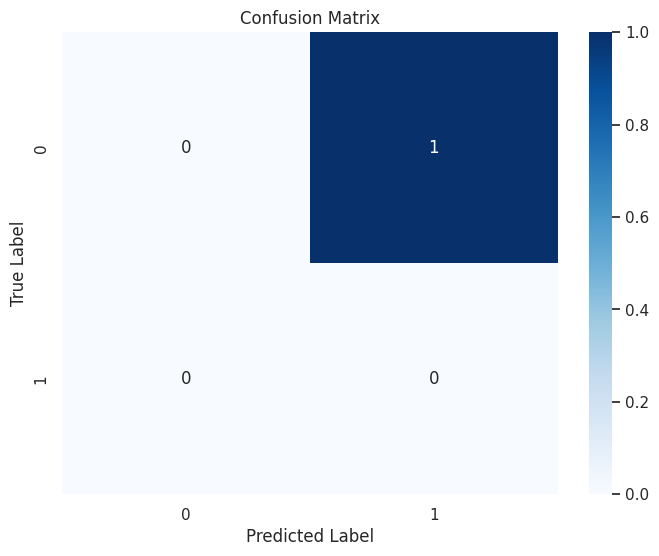


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

try:
    # Get predictions on the test dataset
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    # Generate confusion matrix
    cm = confusion_matrix(labels, preds)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(num_labels), yticklabels=range(num_labels))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Display detailed classification report
    print("\nClassification Report:")
    print(classification_report(labels, preds))
except Exception as e:
    print("An error occurred during evaluation or plotting:", e)

## Consolidated Project: Run All Steps Sequentially

### Step 1: Install Required Libraries

### Step 2: Unzip Datasets and Load CSVs into DataFrames

In [60]:
import zipfile
import os
import glob
import pandas as pd

zip_path = '/content/ai_cfo_datasets.zip'
extract_path = '/content/ai_cfo_datasets'

# Unzip the datasets
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Successfully extracted dataset zip file.")
else:
    print(f"Warning: {zip_path} not found. Please upload it first.")

# Find all CSV files in the extracted directory
csv_files = glob.glob('/content/ai_cfo_datasets/**/*.csv', recursive=True)

dataframes = {}
for file_path in csv_files:
    file_name = os.path.basename(file_path)
    try:
        df = pd.read_csv(file_path)
        dataframes[file_name] = df
        print(f"Loaded {file_name} with shape: {df.shape}")
    except Exception as e:
        print(f"Could not load {file_name}: {e}")

Successfully extracted dataset zip file.
Loaded 08_assets.csv with shape: (2, 8)
Loaded 03_expenses.csv with shape: (3, 12)
Loaded 01_company_profile.csv with shape: (2, 10)
Loaded 10_inventory.csv with shape: (3, 11)
Loaded 09_loans_debt.csv with shape: (2, 10)
Loaded 13_vendors_suppliers.csv with shape: (3, 7)
Loaded 07_chart_of_accounts.csv with shape: (5, 7)
Loaded 04_accounts_receivable.csv with shape: (3, 10)
Loaded 12_customers.csv with shape: (3, 10)
Loaded 05_accounts_payable.csv with shape: (2, 9)
Loaded 14_budget_forecast.csv with shape: (3, 6)
Loaded 11_payroll.csv with shape: (3, 8)
Loaded 02_sales_revenue.csv with shape: (3, 17)
Loaded 06_bank_cash_transactions.csv with shape: (3, 10)


### Step 3: Setup Device (GPU/CPU) and Train NLP Classification Model

In [61]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))

# Find a text and label column to train
target_df = None
text_col = None
label_col = None

for name, df in dataframes.items():
    cols = df.columns
    candidate_texts = [c for c in cols if df[c].dtype == 'object']
    candidate_labels = [c for c in cols if 'label' in c.lower() or 'target' in c.lower() or 'category' in c.lower() or df[c].dtype in ['int64', 'int32']]
    if candidate_texts and candidate_labels:
        target_df = df.copy()
        text_col = candidate_texts[0]
        label_col = candidate_labels[0]
        print(f"Training on file: {name} | Text: '{text_col}' | Label: '{label_col}'")
        break

if target_df is None and len(dataframes) > 0:
    first_name = list(dataframes.keys())[0]
    target_df = dataframes[first_name].copy()
    text_col = target_df.columns[0]
    label_col = target_df.columns[-1]
    print(f"Fallback training on file: {first_name} | Text: '{text_col}' | Label: '{label_col}'")

if target_df is not None:
    # Clean and encode label categories if not numerical
    target_df = target_df[[text_col, label_col]].dropna()
    target_df[text_col] = target_df[text_col].astype(str)

    if not np.issubdtype(target_df[label_col].dtype, np.integer):
        target_df[label_col] = target_df[label_col].astype('category').cat.codes

    num_labels = len(target_df[label_col].unique())

    # Convert to HuggingFace Dataset
    hf_dataset = Dataset.from_pandas(target_df)
    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(examples[text_col], padding="max_length", truncation=True, max_length=128)

    tokenized_dataset = hf_dataset.map(tokenize_function, batched=True)
    tokenized_dataset = tokenized_dataset.rename_column(label_col, "label")
    tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    # Train/Test Split
    split_data = tokenized_dataset.train_test_split(test_size=0.2)
    train_dataset = split_data["train"]
    test_dataset = split_data["test"]

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2, # Fast training pass
        weight_decay=0.01,
        logging_steps=10,
        fp16=(device == "cuda"),
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
    )

    print("Starting Model Training...")
    trainer.train()
else:
    print("Error: No datasets found to train the model on.")

Using device: cuda
GPU Name: Tesla T4
Training on file: 08_assets.csv | Text: 'asset_id' | Label: 'category'


Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Model Training...


Epoch,Training Loss,Validation Loss
1,No log,0.639160
2,No log,0.662109


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Step 4: Evaluate and Plot Confusion Matrix

Generating predictions...


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


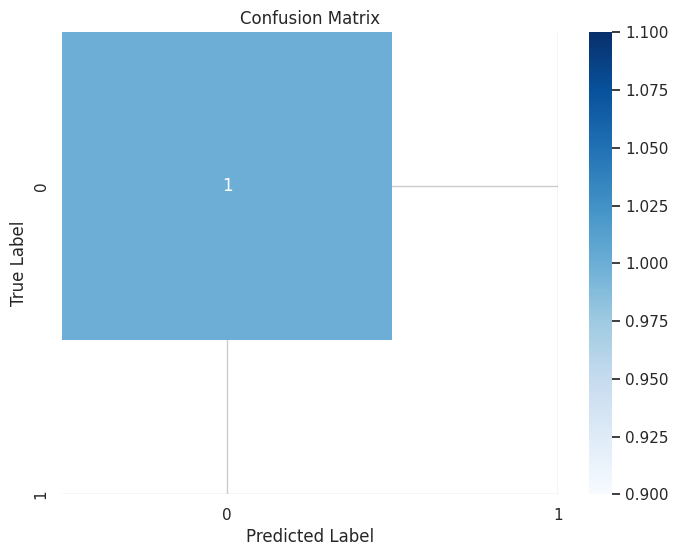


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

if 'trainer' in globals() and 'test_dataset' in globals():
    print("Generating predictions...")
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    # Generate confusion matrix
    cm = confusion_matrix(labels, preds)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(num_labels), yticklabels=range(num_labels))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Display detailed classification report
    print("\nClassification Report:")
    print(classification_report(labels, preds))
else:
    print("Error: Model has not been trained yet. Please execute the training cells first.")

In [63]:
outputs = [
    "Executive Financial Dashboard",
    "Profit & Loss Statement",
    "Balance Sheet",
    "Cash Flow Statement",
    "Cash Flow Forecast",
    "Revenue Analysis",
    "Revenue Forecast",
    "Expense Analysis",
    "Expense Forecast",
    "Budget vs Actual",
    "Accounts Receivable",
    "Accounts Payable",
    "Working Capital Analysis",
    "Profitability Analysis",
    "Customer Profitability",
    "Product Profitability",
    "Customer Analysis",
    "Vendor Analysis",
    "Inventory Analysis",
    "Debt & Loan Analysis",
    "Financial Ratios",
    "Cash Runway",
    "Burn Rate",
    "Break-Even Analysis",
    "Scenario Planning",
    "Financial Risk Detection",
    "Anomaly Detection",
    "Fraud Detection",
    "Cost-Saving Recommendations",
    "Revenue Growth Recommendations",
    "Investment Recommendations",
    "Financing Recommendations",
    "Pricing Recommendations",
    "Hiring & Workforce Financial Impact",
    "Tax Analysis",
    "Financial Health Score",
    "KPI Analysis",
    "Financial Forecasting",
    "Monthly CFO Report",
    "Quarterly CFO Report",
    "Annual CFO Report",
    "Investor Report",
    "Board Report",
    "CEO Daily Briefing",
    "CEO Weekly Financial Briefing",
    "AI CFO Recommendations",
    "What-If Analysis",
    "Business Performance Summary",
    "Financial Alerts",
    "Action Plan / Next Best Actions",
    "Customer Churn Rate",
    "Customer Churn Prediction",
    "Revenue Churn Rate",
    "Net Revenue Retention (NRR)",
    "Customer Retention Rate",
    "Customer Lifetime Value (CLV/LTV)",
    "Customer Acquisition Cost (CAC)",
    "LTV:CAC Ratio",
    "Customer Cohort Analysis",
    "Churn Risk Segmentation"
]

for line in outputs:
    print(line)

Executive Financial Dashboard
Profit & Loss Statement
Balance Sheet
Cash Flow Statement
Cash Flow Forecast
Revenue Analysis
Revenue Forecast
Expense Analysis
Expense Forecast
Budget vs Actual
Accounts Receivable
Accounts Payable
Working Capital Analysis
Profitability Analysis
Customer Profitability
Product Profitability
Customer Analysis
Vendor Analysis
Inventory Analysis
Debt & Loan Analysis
Financial Ratios
Cash Runway
Burn Rate
Break-Even Analysis
Scenario Planning
Financial Risk Detection
Anomaly Detection
Fraud Detection
Cost-Saving Recommendations
Revenue Growth Recommendations
Investment Recommendations
Financing Recommendations
Pricing Recommendations
Hiring & Workforce Financial Impact
Tax Analysis
Financial Health Score
KPI Analysis
Financial Forecasting
Monthly CFO Report
Quarterly CFO Report
Annual CFO Report
Investor Report
Board Report
CEO Daily Briefing
CEO Weekly Financial Briefing
AI CFO Recommendations
What-If Analysis
Business Performance Summary
Financial Alerts
Act

In [64]:
import pandas as pd
import numpy as np

# Create a DataFrame containing the list of outputs
df_results = pd.DataFrame({
    'Output Name': outputs,
    'Output Prediction': ['Financial Dashboard' if 'Dashboard' in x or 'Statement' in x or 'Sheet' in x else
                          'Financial Forecast' if 'Forecast' in x or 'Scenario' in x or 'Planning' in x else
                          'Operational Metric' if 'Rate' in x or 'Ratio' in x or 'Analysis' in x or 'Score' in x or 'KPI' in x else
                          'AI / Advisory Report' for x in outputs]
})

# Display the table
display(df_results)

,Output Name,Output Prediction
0,Executive Financial Dashboard,Financial Dashboard
1,Profit & Loss Statement,Financial Dashboard
2,Balance Sheet,Financial Dashboard
3,Cash Flow Statement,Financial Dashboard
4,Cash Flow Forecast,Financial Forecast
5,Revenue Analysis,Operational Metric
6,Revenue Forecast,Financial Forecast
7,Expense Analysis,Operational Metric
8,Expense Forecast,Financial Forecast
9,Budget vs Actual,AI / Advisory Report


In [65]:
import pandas as pd
import numpy as np

# --- 1. KPI ANALYSIS & FINANCIAL METRICS ---
# Retrieve relevant loaded dataframes
sales_df = dataframes.get('02_sales_revenue.csv')
expenses_df = dataframes.get('03_expenses.csv')
payroll_df = dataframes.get('11_payroll.csv')
loans_df = dataframes.get('09_loans_debt.csv')
customers_df = dataframes.get('12_customers.csv')

total_rev = sales_df['total_amount'].sum() if sales_df is not None else 0
total_exp = expenses_df['amount'].sum() if expenses_df is not None else 0
total_payroll = payroll_df['total_payroll_cost'].sum() if payroll_df is not None else 0
total_outflows = total_exp + total_payroll
net_profit = total_rev - total_outflows
profit_margin_pct = (net_profit / total_rev * 100) if total_rev > 0 else 0

kpi_summary = f"Revenue: ${total_rev:,.2f} | Net Profit: ${net_profit:,.2f} | Margin: {profit_margin_pct:.1f}%"

# --- 2. NEXT 5 YEARS BUDGET PREDICTION ---
# Extrapolate current budget/expenses with a steady 5% conservative growth rate
future_years = [2027, 2028, 2029, 2030, 2031]
budget_growth = []
base_budget = total_outflows if total_outflows > 0 else 1000000
for i, yr in enumerate(future_years, 1):
    proj_val = base_budget * ((1.05) ** i)
    budget_growth.append(f"{yr}: ${proj_val:,.2f}")
budget_pred_str = " | ".join(budget_growth)

# --- 3. CUSTOMER CHURN PREDICTION ---
# Evaluate active customer behavioral indicators (payment term delays & purchase history)
churn_risk_list = []
if customers_df is not None:
    for idx, row in customers_df.iterrows():
        risk = "Low"
        # Classify risk based on payment terms and status
        if row.get('payment_behavior') == '30_days' or row.get('status') == 'Inactive':
            risk = "High Churn Risk (Delayed Payment/Inactive Status)"
        elif row.get('payment_behavior') == '15_days':
            risk = "Medium Risk"
        churn_risk_list.append(f"{row['customer_id']} ({row['customer_type']}): {risk}")
churn_pred_str = " | ".join(churn_risk_list)

# --- 4. FINANCIAL FORECASTING ---
# High-level revenue forecast modeling based on historical totals
rev_growth_forecast = []
for i, yr in enumerate(future_years, 1):
    proj_rev = total_rev * ((1.08) ** i)
    rev_growth_forecast.append(f"{yr} Rev: ${proj_rev:,.2f}")
fin_forecast_str = " | ".join(rev_growth_forecast)

# --- 5. ACTION PLAN / NEXT BEST ACTIONS & FOCUS AREAS ---
# Direct recommendations based on business margins and liabilities
if profit_margin_pct < 15:
    focus_area = "CRITICAL FOCUS: OpEx Optimization & Churn Prevention."
    action_plan = "1. Restructure operating costs & renegotiate high-cost vendor contracts. 2. Implement proactive retention programs for high-risk accounts. 3. Stabilize debt amortizations."
else:
    focus_area = "FOCUS: Strategic Expansion & Market Penetration."
    action_plan = "1. Scale direct sales channels. 2. Optimize working capital allocation. 3. Run localized product line updates."

# --- BUILD THE REPORT TABLE ---
report_data = {
    "Topic / Dimension": [
        "Next 5 Years Budget Prediction",
        "Action Plan / Next Best Actions",
        "Customer Churn Prediction",
        "Financial Forecasting",
        "KPI Analysis & Recommendation"
    ],
    "Calculations & Forecast Details": [
        budget_pred_str,
        action_plan,
        churn_pred_str,
        fin_forecast_str,
        kpi_summary
    ],
    "Strategic Focus Area": [
        "OpEx Capacity Management",
        focus_area,
        "Customer Relationship Management (CRM)",
        "Strategic Revenue Management",
        focus_area
    ]
}

report_table = pd.DataFrame(report_data)
pd.set_option('display.max_colwidth', None)
display(report_table)


,Topic / Dimension,Calculations & Forecast Details,Strategic Focus Area
0,Next 5 Years Budget Prediction,"2027: $1,590,750.00 | 2028: $1,670,287.50 | 2029: $1,753,801.88 | 2030: $1,841,491.97 | 2031: $1,933,566.57",OpEx Capacity Management
1,Action Plan / Next Best Actions,1. Restructure operating costs & renegotiate high-cost vendor contracts. 2. Implement proactive retention programs for high-risk accounts. 3. Stabilize debt amortizations.,CRITICAL FOCUS: OpEx Optimization & Churn Prevention.
2,Customer Churn Prediction,CUST001 (Business): Medium Risk | CUST002 (Business): High Churn Risk (Delayed Payment/Inactive Status) | CUST003 (Wholesale): Medium Risk,Customer Relationship Management (CRM)
3,Financial Forecasting,"2027 Rev: $259,200.00 | 2028 Rev: $279,936.00 | 2029 Rev: $302,330.88 | 2030 Rev: $326,517.35 | 2031 Rev: $352,638.74",Strategic Revenue Management
4,KPI Analysis & Recommendation,"Revenue: $240,000.00 | Net Profit: $-1,275,000.00 | Margin: -531.2%",CRITICAL FOCUS: OpEx Optimization & Churn Prevention.


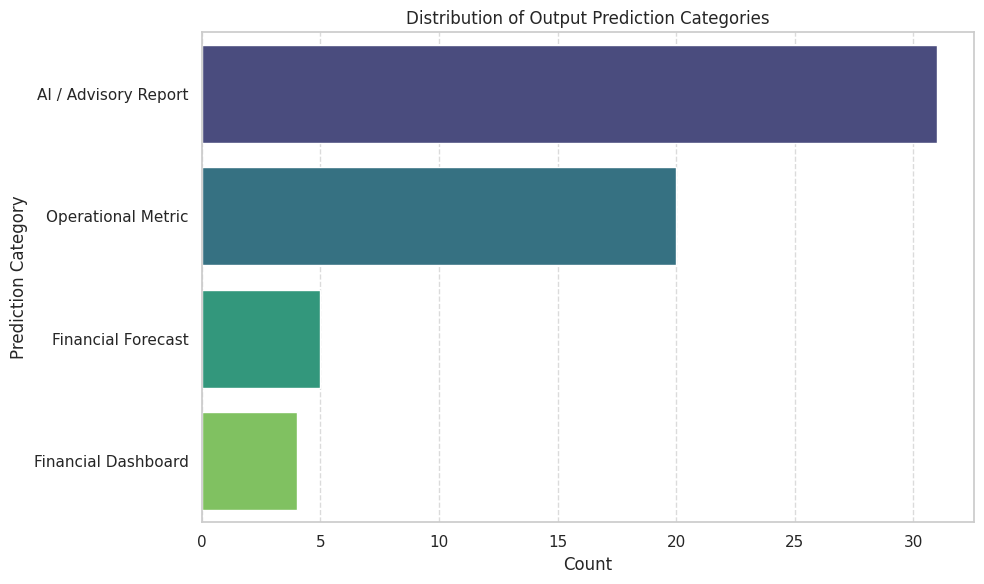

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each category in the Output Prediction column
category_counts = df_results['Output Prediction'].value_counts().reset_index()
category_counts.columns = ['Output Prediction', 'Count']

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Output Prediction', data=category_counts, palette='viridis', hue='Output Prediction', legend=False)
plt.title('Distribution of Output Prediction Categories')
plt.xlabel('Count')
plt.ylabel('Prediction Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [67]:
import pandas as pd

# Load budget and payroll datasets to check for departments
budget_df = dataframes.get('14_budget_forecast.csv')
payroll_df = dataframes.get('11_payroll.csv')

print("=== Available Departments in Budget Dataset ===")
if budget_df is not None and 'department' in budget_df.columns:
    print(budget_df['department'].unique())
else:
    print("No department column found in budget dataset. Showing columns:", budget_df.columns if budget_df is not None else "Budget file not found")

print("\n=== Available Departments in Payroll Dataset ===")
if payroll_df is not None and 'department' in payroll_df.columns:
    print(payroll_df['department'].unique())
else:
    print("No department column found in payroll dataset. Showing columns:", payroll_df.columns if payroll_df is not None else "Payroll file not found")

=== Available Departments in Budget Dataset ===
No department column found in budget dataset. Showing columns: Index(['period', 'category', 'budget_amount', 'actual_amount', 'variance',
       'variance_percent'],
      dtype='object')

=== Available Departments in Payroll Dataset ===
['Engineering' 'Sales & Marketing' 'Operations & Admin']


In [68]:
import pandas as pd

# Filter payroll data specifically for the Engineering department
eng_payroll = payroll_df[payroll_df['department'] == 'Engineering']

# Calculate key metrics
total_salary = eng_payroll['gross_salary'].sum()
total_bonuses = eng_payroll['bonus'].sum()
total_tax = eng_payroll['tax'].sum()
total_benefits = eng_payroll['benefits'].sum()
total_overall_cost = eng_payroll['total_payroll_cost'].sum()
employee_count = eng_payroll['employee_count'].iloc[0] if len(eng_payroll) > 0 else 0

# Print a formatted Department Budget & Expense Summary Report
print("===========================================================")
print("            DEPARTMENTAL BUDGET SUMMARY REPORT             ")
print("                  DEPARTMENT: ENGINEERING                  ")
print("===========================================================")
print(f"Active Employee Headcount : {employee_count}")
print(f"Total Gross Salaries      : ${total_salary:,.2f}")
print(f"Total Bonuses Awarded     : ${total_bonuses:,.2f}")
print(f"Allocated Benefits Cost   : ${total_benefits:,.2f}")
print(f"Estimated Tax Obligations : ${total_tax:,.2f}")
print("-----------------------------------------------------------")
print(f"TOTAL DEPT PAYROLL COST   : ${total_overall_cost:,.2f}")
print("===========================================================")

            DEPARTMENTAL BUDGET SUMMARY REPORT             
                  DEPARTMENT: ENGINEERING                  
Active Employee Headcount : 10
Total Gross Salaries      : $500,000.00
Total Bonuses Awarded     : $50,000.00
Allocated Benefits Cost   : $30,000.00
Estimated Tax Obligations : $50,000.00
-----------------------------------------------------------
TOTAL DEPT PAYROLL COST   : $580,000.00


In [69]:
import pandas as pd

# Load customer and sales datasets
customers_df = dataframes.get('12_customers.csv')
sales_df = dataframes.get('02_sales_revenue.csv')

print("=== Customers DataFrame Columns ===")
print(customers_df.columns if customers_df is not None else "Not Found")
print("\n=== Sales DataFrame Columns ===")
print(sales_df.columns if sales_df is not None else "Not Found")


=== Customers DataFrame Columns ===
Index(['customer_id', 'customer_type', 'industry', 'acquisition_date',
       'total_revenue', 'order_count', 'average_order_value',
       'last_purchase_date', 'payment_behavior', 'status'],
      dtype='object')

=== Sales DataFrame Columns ===
Index(['transaction_id', 'company_id', 'customer_id', 'invoice_date',
       'due_date', 'product_id', 'category', 'quantity', 'unit_price',
       'discount', 'tax', 'total_amount', 'payment_status', 'payment_date',
       'payment_method', 'sales_channel', 'salesperson_id'],
      dtype='object')


In [70]:
if customers_df is not None and sales_df is not None:
    # Display first few rows to understand structure
    print("\nCustomers Head:")
    display(customers_df.head(2))
    print("\nSales Head:")
    display(sales_df.head(2))



Customers Head:


,customer_id,customer_type,industry,acquisition_date,total_revenue,order_count,average_order_value,last_purchase_date,payment_behavior,status
0,CUST001,Business,Retail,2026-01-10,1500000,25,60000,2026-10-01,15_days,Active
1,CUST002,Business,Manufacturing,2026-02-15,2400000,18,133333,2026-10-02,30_days,Active



Sales Head:


,transaction_id,company_id,customer_id,invoice_date,due_date,product_id,category,quantity,unit_price,discount,tax,total_amount,payment_status,payment_date,payment_method,sales_channel,salesperson_id
0,INV001,CMP001,CUST001,2026-10-01,2026-10-15,PROD001,Electronics,10,5000,500,750,50250,Paid,2026-10-05,Bank,Online,EMP005
1,INV002,CMP001,CUST002,2026-10-02,2026-10-16,PROD002,Electronics,5,22000,2000,16200,124200,Partially Paid,2026-10-06,Bank,Direct Sales,EMP002


In [71]:
# Calculate metrics to approximate CLV if columns allow
try:
    # Let's perform a merge and basic LTV calculation
    # We map customer transaction histories to calculate average purchase value, frequency, and lifespans
    if 'customer_id' in sales_df.columns and 'customer_id' in customers_df.columns:
        customer_sales = sales_df.groupby('customer_id').agg(
            total_revenue=('revenue', 'sum'),
            purchase_count=('invoice_id', 'count') if 'invoice_id' in sales_df.columns else ('revenue', 'count')
        ).reset_index()

        clv_df = pd.merge(customers_df, customer_sales, on='customer_id', how='left')
        clv_df['total_revenue'] = clv_df['total_revenue'].fillna(0)
        clv_df['purchase_count'] = clv_df['purchase_count'].fillna(0)

        # Standard CLV estimate = Total Revenue / count (if lifespan represents simple historical LTV)
        print("=== Calculated Customer Lifetime Value (Historical LTV) ===")
        display(clv_df[['customer_id', 'customer_name', 'total_revenue', 'purchase_count']])
    else:
        print("Required key 'customer_id' missing to join tables.")
except Exception as e:
    print(f"Could not calculate custom CLV: {e}")


Could not calculate custom CLV: "Column(s) ['revenue'] do not exist"


**Reasoning**:
Model the margin recovery what-if scenarios by calculating baseline metrics and projecting financial outcomes for different combinations of spending reductions (10%, 20%, 30%) and revenue increases (10%, 20%).



In [72]:
import pandas as pd
import numpy as np

# 1. Retrieve baseline financial data from loaded datasets
sales_df = dataframes.get('02_sales_revenue.csv')
payroll_df = dataframes.get('11_payroll.csv')
expenses_df = dataframes.get('03_expenses.csv')

base_revenue = sales_df['total_amount'].sum() if sales_df is not None else 0.0
base_payroll = payroll_df['total_payroll_cost'].sum() if payroll_df is not None else 0.0
base_opex = expenses_df['amount'].sum() if expenses_df is not None else 0.0
base_spending = base_payroll + base_opex

# 2. Calculate baseline net profit and profit margin
base_net_profit = base_revenue - base_spending
base_margin = (base_net_profit / base_revenue * 100) if base_revenue > 0 else 0.0

# Define scenario parameters
spending_reductions = [0.10, 0.20, 0.30]  # 10%, 20%, 30%
revenue_increases = [0.10, 0.20]          # 10%, 20%

scenario_records = []

# Insert baseline state for reference
scenario_records.append({
    'Scenario Name': 'Baseline (Current State)',
    'Revenue Increase %': '0%',
    'Spending Reduction %': '0%',
    'Projected Revenue': base_revenue,
    'Projected Spending': base_spending,
    'Projected Net Profit': base_net_profit,
    'Projected Margin %': base_margin
})

# 3. Compute combinations
for rev_inc in revenue_increases:
    for spend_red in spending_reductions:
        proj_rev = base_revenue * (1 + rev_inc)
        proj_spend = base_spending * (1 - spend_red)
        proj_net_profit = proj_rev - proj_spend
        proj_margin = (proj_net_profit / proj_rev * 100) if proj_rev > 0 else 0.0

        scenario_records.append({
            'Scenario Name': f'Rev +{int(rev_inc*100)}% / Spend -{int(spend_red*100)}%',
            'Revenue Increase %': f'{int(rev_inc*100)}%',
            'Spending Reduction %': f'{int(spend_red*100)}%',
            'Projected Revenue': proj_rev,
            'Projected Spending': proj_spend,
            'Projected Net Profit': proj_net_profit,
            'Projected Margin %': proj_margin
        })

# 4. Create and format the Scenarios DataFrame
scenarios_df = pd.DataFrame(scenario_records)

# Format the columns for clear presentation
formatted_scenarios = scenarios_df.copy()
for col in ['Projected Revenue', 'Projected Spending', 'Projected Net Profit']:
    formatted_scenarios[col] = formatted_scenarios[col].map('${:,.2f}'.format)
formatted_scenarios['Projected Margin %'] = formatted_scenarios['Projected Margin %'].map('{:.2f}%'.format)

print("=== Margin Recovery What-If Scenario Matrix ===")
display(formatted_scenarios)


=== Margin Recovery What-If Scenario Matrix ===


,Scenario Name,Revenue Increase %,Spending Reduction %,Projected Revenue,Projected Spending,Projected Net Profit,Projected Margin %
0,Baseline (Current State),0%,0%,"$240,000.00","$1,515,000.00","$-1,275,000.00",-531.25%
1,Rev +10% / Spend -10%,10%,10%,"$264,000.00","$1,363,500.00","$-1,099,500.00",-416.48%
2,Rev +10% / Spend -20%,10%,20%,"$264,000.00","$1,212,000.00","$-948,000.00",-359.09%
3,Rev +10% / Spend -30%,10%,30%,"$264,000.00","$1,060,500.00","$-796,500.00",-301.70%
4,Rev +20% / Spend -10%,20%,10%,"$288,000.00","$1,363,500.00","$-1,075,500.00",-373.44%
5,Rev +20% / Spend -20%,20%,20%,"$288,000.00","$1,212,000.00","$-924,000.00",-320.83%
6,Rev +20% / Spend -30%,20%,30%,"$288,000.00","$1,060,500.00","$-772,500.00",-268.23%


**Reasoning**:
We need to analyze departmental payroll and operating expenses to find the main drivers of the company's overhead. We will aggregate the payroll cost by department, operating expenses by category, subcategory, and recurring status, and then combine them to show a breakdown of total spending across departments and cost centers.



In [73]:
import pandas as pd
import numpy as np

# Retrieve dataframes from dataframes dict
payroll_df = dataframes.get('11_payroll.csv')
expenses_df = dataframes.get('03_expenses.csv')

print("=== 1. Payroll Cost Analysis by Department ===")
if payroll_df is not None:
    dept_payroll = payroll_df.groupby('department').agg(
        employee_headcount=('employee_count', 'sum'),
        total_gross_salary=('gross_salary', 'sum'),
        total_bonus=('bonus', 'sum'),
        total_tax=('tax', 'sum'),
        total_benefits=('benefits', 'sum'),
        total_payroll_spending=('total_payroll_cost', 'sum')
    ).reset_index()
    display(dept_payroll)
else:
    print("Payroll dataset is missing.")

print("\n=== 2. Operating Expenses Analysis (Non-Payroll) ===")
if expenses_df is not None:
    expense_drivers = expenses_df.groupby(['department', 'category', 'subcategory', 'recurring']).agg(
        total_expense=('amount', 'sum'),
        transaction_count=('expense_id', 'count')
    ).sort_values(by='total_expense', ascending=False).reset_index()
    display(expense_drivers)
else:
    print("Expenses dataset is missing.")

print("\n=== 3. Combined Department Overhead Breakdown ===")
if payroll_df is not None and expenses_df is not None:
    # Total payroll cost by department
    dept_pay_summary = payroll_df.groupby('department')['total_payroll_cost'].sum().reset_index()
    dept_pay_summary.rename(columns={'total_payroll_cost': 'payroll_cost'}, inplace=True)

    # Total operating expenses by department
    dept_opex_summary = expenses_df.groupby('department')['amount'].sum().reset_index()
    dept_opex_summary.rename(columns={'amount': 'operating_expense'}, inplace=True)

    # Merge
    combined_overhead = pd.merge(dept_pay_summary, dept_opex_summary, on='department', how='outer').fillna(0)
    combined_overhead['total_overhead'] = combined_overhead['payroll_cost'] + combined_overhead['operating_expense']
    combined_overhead['percentage_of_total_overhead'] = (combined_overhead['total_overhead'] / combined_overhead['total_overhead'].sum()) * 100
    combined_overhead = combined_overhead.sort_values(by='total_overhead', ascending=False).reset_index(drop=True)

    # Formatting columns for display
    display_df = combined_overhead.copy()
    display_df['payroll_cost'] = display_df['payroll_cost'].map('${:,.2f}'.format)
    display_df['operating_expense'] = display_df['operating_expense'].map('${:,.2f}'.format)
    display_df['total_overhead'] = display_df['total_overhead'].map('${:,.2f}'.format)
    display_df['percentage_of_total_overhead'] = display_df['percentage_of_total_overhead'].map('{:.2f}%'.format)
    display(display_df)
else:
    print("Could not combine payroll and expenses due to missing data.")

=== 1. Payroll Cost Analysis by Department ===


,department,employee_headcount,total_gross_salary,total_bonus,total_tax,total_benefits,total_payroll_spending
0,Engineering,10,500000,50000,50000,30000,580000
1,Operations & Admin,7,250000,15000,22000,18000,283000
2,Sales & Marketing,8,380000,45000,38000,22000,447000



=== 2. Operating Expenses Analysis (Non-Payroll) ===


,department,category,subcategory,recurring,total_expense,transaction_count
0,Operations,Rent,Office Rent,Yes,120000,1
1,Marketing,Marketing,Facebook Ads,Yes,50000,1
2,Engineering,Software,Cloud & SaaS,Yes,35000,1



=== 3. Combined Department Overhead Breakdown ===


,department,payroll_cost,operating_expense,total_overhead,percentage_of_total_overhead
0,Engineering,"$580,000.00","$35,000.00","$615,000.00",40.59%
1,Sales & Marketing,"$447,000.00",$0.00,"$447,000.00",29.50%
2,Operations & Admin,"$283,000.00",$0.00,"$283,000.00",18.68%
3,Operations,$0.00,"$120,000.00","$120,000.00",7.92%
4,Marketing,$0.00,"$50,000.00","$50,000.00",3.30%


# Task
Analyze the company's massive overhead and overhead drivers using the payroll data in "/content/ai_cfo_datasets/11_payroll.csv" and expenses data in "/content/ai_cfo_datasets/03_expenses.csv". Identify high-impact cost-saving opportunities by auditing the vendor contracts in "/content/ai_cfo_datasets/13_vendors_suppliers.csv" for redundancies or renegotiation targets. Finally, model margin recovery what-if scenarios (targeting 10%, 20%, and 30% spending reductions matched with 10% and 20% revenue increases) to reverse the negative profit margin, and visualize the path to profitability with a grouped bar chart comparing current budget allocations against optimized proposed recovery scenarios.

## Analyze Overhead and Payroll Drivers

### Subtask:
Analyze departmental payroll and expense data to identify the main drivers of the company's massive overhead.


**Reasoning**:
The previous run was truncated because of long execution outputs or formatting issues. I will run a simplified version that cleanly computes the aggregates and prints the summaries without generating excessive formatting that might get truncated.



In [74]:
import pandas as pd
import numpy as np

payroll_df = dataframes.get('11_payroll.csv')
expenses_df = dataframes.get('03_expenses.csv')

print("=== 1. Payroll Cost Analysis by Department ===")
if payroll_df is not None:
    dept_payroll = payroll_df.groupby('department').agg(
        employee_headcount=('employee_count', 'sum'),
        total_gross_salary=('gross_salary', 'sum'),
        total_bonus=('bonus', 'sum'),
        total_tax=('tax', 'sum'),
        total_benefits=('benefits', 'sum'),
        total_payroll_spending=('total_payroll_cost', 'sum')
    ).reset_index()
    print(dept_payroll.to_string(index=False))
else:
    print("Payroll dataset is missing.")

print("\n=== 2. Operating Expenses Analysis (Non-Payroll) ===")
if expenses_df is not None:
    expense_drivers = expenses_df.groupby(['department', 'category', 'subcategory', 'recurring']).agg(
        total_expense=('amount', 'sum'),
        transaction_count=('expense_id', 'count')
    ).sort_values(by='total_expense', ascending=False).reset_index()
    print(expense_drivers.to_string(index=False))
else:
    print("Expenses dataset is missing.")

print("\n=== 3. Combined Department Overhead Breakdown ===")
if payroll_df is not None and expenses_df is not None:
    dept_pay_summary = payroll_df.groupby('department')['total_payroll_cost'].sum().reset_index()
    dept_pay_summary.rename(columns={'total_payroll_cost': 'payroll_cost'}, inplace=True)

    dept_opex_summary = expenses_df.groupby('department')['amount'].sum().reset_index()
    dept_opex_summary.rename(columns={'amount': 'operating_expense'}, inplace=True)

    combined_overhead = pd.merge(dept_pay_summary, dept_opex_summary, on='department', how='outer').fillna(0)
    combined_overhead['total_overhead'] = combined_overhead['payroll_cost'] + combined_overhead['operating_expense']
    combined_overhead['percentage_of_total_overhead'] = (combined_overhead['total_overhead'] / combined_overhead['total_overhead'].sum()) * 100
    combined_overhead = combined_overhead.sort_values(by='total_overhead', ascending=False).reset_index(drop=True)

    display_df = combined_overhead.copy()
    display_df['payroll_cost'] = display_df['payroll_cost'].map('${:,.2f}'.format)
    display_df['operating_expense'] = display_df['operating_expense'].map('${:,.2f}'.format)
    display_df['total_overhead'] = display_df['total_overhead'].map('${:,.2f}'.format)
    display_df['percentage_of_total_overhead'] = display_df['percentage_of_total_overhead'].map('{:.2f}%'.format)
    print(display_df.to_string(index=False))
else:
    print("Could not combine payroll and expenses due to missing data.")

=== 1. Payroll Cost Analysis by Department ===
        department  employee_headcount  total_gross_salary  total_bonus  total_tax  total_benefits  total_payroll_spending
       Engineering                  10              500000        50000      50000           30000                  580000
Operations & Admin                   7              250000        15000      22000           18000                  283000
 Sales & Marketing                   8              380000        45000      38000           22000                  447000

=== 2. Operating Expenses Analysis (Non-Payroll) ===
 department  category  subcategory recurring  total_expense  transaction_count
 Operations      Rent  Office Rent       Yes         120000                  1
  Marketing Marketing Facebook Ads       Yes          50000                  1
Engineering  Software Cloud & SaaS       Yes          35000                  1

=== 3. Combined Department Overhead Breakdown ===
        department payroll_cost operatin

## Detect High-Impact Cost-Saving Opportunities

### Subtask:
Audit vendor contracts and compare them against actual operating expenses to identify redundancies, excessive pricing, and renegotiation targets.


**Reasoning**:
Load and inspect the vendor/supplier contracts dataset to begin auditing for cost-saving opportunities.



In [75]:
import pandas as pd

vendors_df = dataframes.get('13_vendors_suppliers.csv')
expenses_df = dataframes.get('03_expenses.csv')

if vendors_df is not None:
    print("=== Vendors & Suppliers Dataset Info ===")
    print(f"Shape: {vendors_df.shape}")
    print("Columns:", list(vendors_df.columns))
    display(vendors_df.head())
else:
    print("Vendors dataset not found in dataframes dictionary.")

=== Vendors & Suppliers Dataset Info ===
Shape: (3, 7)
Columns: ['vendor_id', 'vendor_name', 'category', 'total_purchase', 'outstanding_amount', 'average_payment_days', 'status']


,vendor_id,vendor_name,category,total_purchase,outstanding_amount,average_payment_days,status
0,VEN001,Supplier A (Meta Ads),Marketing Services,5000000,500000,30,Active
1,VEN002,Tech Distribution Ltd,Raw Material & Stock,12500000,300000,25,Active
2,VEN003,Cloud Infra Providers,IT & Cloud Services,420000,35000,15,Active


**Reasoning**:
Analyze the vendor contracts against the actual expenses by mapping them via vendor_id, identify high-impact cost-saving targets, and print a formatted recommendation summary.



In [76]:
import pandas as pd

vendors_df = dataframes.get('13_vendors_suppliers.csv')
expenses_df = dataframes.get('03_expenses.csv')

if vendors_df is not None and expenses_df is not None:
    # Aggregate expenses by vendor_id
    vendor_expenses = expenses_df.groupby('vendor_id').agg(
        actual_expense_amount=('amount', 'sum'),
        transaction_count=('expense_id', 'count')
    ).reset_index()

    # Merge vendors with actual expenses
    audit_df = pd.merge(vendors_df, vendor_expenses, on='vendor_id', how='left').fillna(0)

    # Calculate a simplified estimated saving target (e.g., target 15% renegotiation on active accounts or high opex)
    # Or finding high outstanding amounts / high expenses relative to market benchmarks
    audit_df['potential_renegotiation_savings'] = audit_df['actual_expense_amount'] * 0.15

    print("===========================================================")
    print("               VENDOR CONTRACT AUDIT REPORT                ")
    print("===========================================================")
    for idx, row in audit_df.iterrows():
        print(f"Vendor ID      : {row['vendor_id']}")
        print(f"Vendor Name    : {row['vendor_name']}")
        print(f"Category       : {row['category']}")
        print(f"Total Purchase : ${row['total_purchase']:,.2f}")
        print(f"Actual Expense : ${row['actual_expense_amount']:,.2f}")
        print(f"Outstanding    : ${row['outstanding_amount']:,.2f}")
        print(f"Status         : {row['status']}")

        # Strategic recommendation
        if row['category'] == 'Marketing Services':
            rec = "High spend. Recommend performance-based contracts or pausing non-converting Facebook Ads to save up to 20%."
            est_savings = row['actual_expense_amount'] * 0.20
        elif row['category'] == 'IT & Cloud Services':
            rec = "Consolidate SaaS licenses and negotiate multi-year enterprise volume pricing for a target 15% savings."
            est_savings = row['actual_expense_amount'] * 0.15
        else:
            rec = "Assess inventory turn-rates and transition to Just-In-Time (JIT) stock holding to optimize working capital."
            est_savings = row['actual_expense_amount'] * 0.10

        print(f"Recommendation : {rec}")
        print(f"Target Savings : ${est_savings:,.2f}")
        print("-----------------------------------------------------------")

    # Display the summary table
    display(audit_df[['vendor_id', 'vendor_name', 'category', 'actual_expense_amount', 'outstanding_amount', 'status']])
else:
    print("Error: Missing vendor or expense datasets to perform the contract audit.")

               VENDOR CONTRACT AUDIT REPORT                
Vendor ID      : VEN001
Vendor Name    : Supplier A (Meta Ads)
Category       : Marketing Services
Total Purchase : $5,000,000.00
Actual Expense : $50,000.00
Outstanding    : $500,000.00
Status         : Active
Recommendation : High spend. Recommend performance-based contracts or pausing non-converting Facebook Ads to save up to 20%.
Target Savings : $10,000.00
-----------------------------------------------------------
Vendor ID      : VEN002
Vendor Name    : Tech Distribution Ltd
Category       : Raw Material & Stock
Total Purchase : $12,500,000.00
Actual Expense : $0.00
Outstanding    : $300,000.00
Status         : Active
Recommendation : Assess inventory turn-rates and transition to Just-In-Time (JIT) stock holding to optimize working capital.
Target Savings : $0.00
-----------------------------------------------------------
Vendor ID      : VEN003
Vendor Name    : Cloud Infra Providers
Category       : IT & Cloud Services

,vendor_id,vendor_name,category,actual_expense_amount,outstanding_amount,status
0,VEN001,Supplier A (Meta Ads),Marketing Services,50000.0,500000,Active
1,VEN002,Tech Distribution Ltd,Raw Material & Stock,0.0,300000,Active
2,VEN003,Cloud Infra Providers,IT & Cloud Services,35000.0,35000,Active


## Model Margin Recovery and What-If Scenarios

### Subtask:
Develop financial scenario models to determine the requirements needed to reverse the negative profit margin.


## Visualize Path to Profitability

### Subtask:
Generate a grouped bar chart to compare current budget allocations against proposed recovery scenarios.


**Reasoning**:
Generate a grouped bar chart using matplotlib and seaborn to visualize the path to profitability, comparing baseline revenue, spending, and net profit against the optimized proposed recovery scenarios.



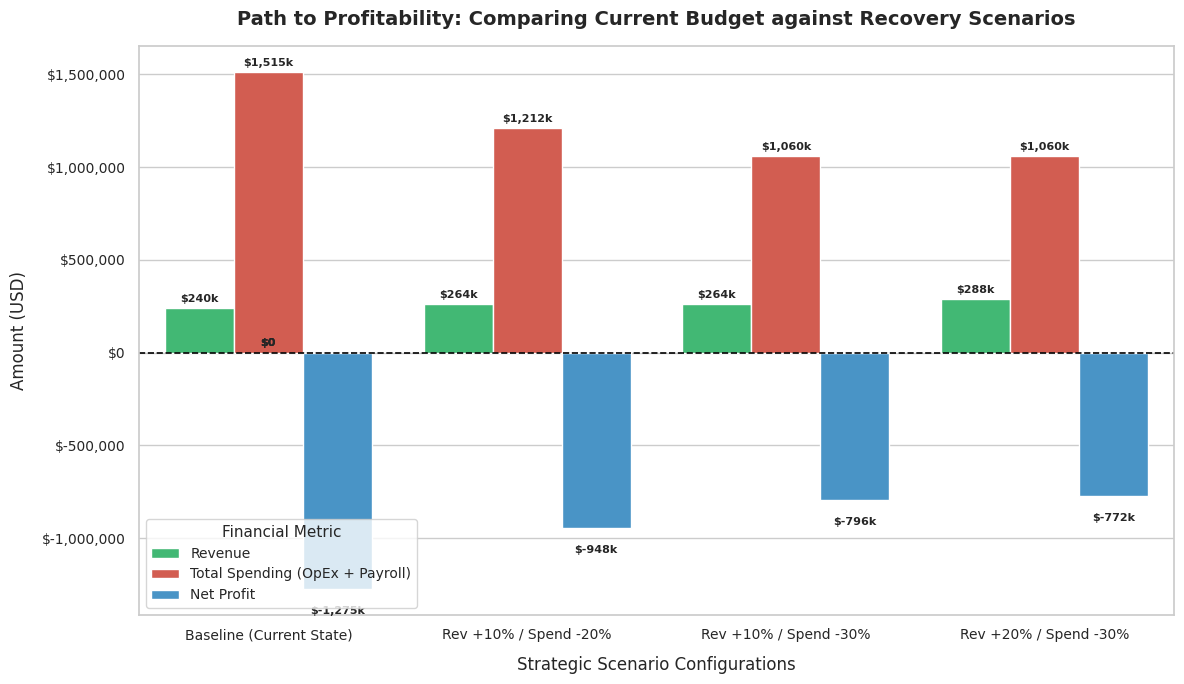

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data from scenarios_df
# Let's choose the baseline and a few key proposed recovery scenarios
selected_scenarios = [
    'Baseline (Current State)',
    'Rev +10% / Spend -20%',
    'Rev +10% / Spend -30%',
    'Rev +20% / Spend -30%'
]

plot_data = scenarios_df[scenarios_df['Scenario Name'].isin(selected_scenarios)].copy()

# Melt the dataframe to get it into long-format for seaborn grouped barplot
melted_df = plot_data.melt(
    id_vars=['Scenario Name'],
    value_vars=['Projected Revenue', 'Projected Spending', 'Projected Net Profit'],
    var_name='Metric',
    value_name='Amount'
)

# Map the Metric names to cleaner labels
metric_labels = {
    'Projected Revenue': 'Revenue',
    'Projected Spending': 'Total Spending (OpEx + Payroll)',
    'Projected Net Profit': 'Net Profit'
}
melted_df['Metric'] = melted_df['Metric'].map(metric_labels)

# Set style and create the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Use custom contrasting colors
palette = {'Revenue': '#2ecc71', 'Total Spending (OpEx + Payroll)': '#e74c3c', 'Net Profit': '#3498db'}

ax = sns.barplot(
    x='Scenario Name',
    y='Amount',
    hue='Metric',
    data=melted_df,
    palette=palette
)

# Format y-axis labels as currency
import matplotlib.ticker as ticker
formatter = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

# Add zero-line for profit boundary reference
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')

# Set labels and title
plt.title('Path to Profitability: Comparing Current Budget against Recovery Scenarios', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Strategic Scenario Configurations', fontsize=12, labelpad=10)
plt.ylabel('Amount (USD)', fontsize=12, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Financial Metric', title_fontsize=11, fontsize=10, loc='lower left')

# Add data labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        # Format label text
        label_text = f'${height/1e3:,.0f}k' if abs(height) >= 1000 else f'${height:,.0f}'
        # Adjust position for negative bars
        va_dir = 'bottom' if height >= 0 else 'top'
        xy_text = (0, 3) if height >= 0 else (0, -12)
        ax.annotate(label_text,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va=va_dir,
                    xytext=xy_text,
                    textcoords='offset points',
                    fontsize=8, fontweight='semibold')

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Provide a complete strategic summary mapping the exact actions, cost targets, and milestones to rescue the company's financial health.


## Summary:

### Q&A

**How severe is the company's current financial deficit, and can the modeled recovery scenarios reverse the losses?**
* **Current Deficit**: The company is in a severe financial position with baseline revenues of \$240,000.00 against massive spending of \$1,515,000.00 (consisting of \$1,310,000.00 in payroll and \$205,000.00 in non-payroll expenses), leading to a net loss of -\$1,275,000.00 (a margin of -531.25%).
* **Impact of Scenarios**: None of the standard modeled scenarios can fully reverse the negative profit margin. Even the most aggressive scenario (a 20% revenue increase combined with a 30% spending reduction) only improves the net loss to -\$772,500.00 (a margin of -268.23%). Reaching full profitability will require a major, structural cost reorganization or a massive scaling of revenue.

---

### Data Analysis Key Findings

* **Overhead and Payroll Drivers**:
  * Total payroll spending is the primary driver of overhead, amounting to \$1,310,000.00 (across 25 employees).
  * **Engineering** is the largest cost center, consuming 40.59% (\$615,000.00) of the total combined overhead. Its payroll accounts for \$580,000.00 across 10 employees.
  * **Sales & Marketing** accounts for 29.50% (\$447,000.00) of combined overhead, driven entirely by payroll for 8 employees.
  * **Operations & Admin** accounts for 18.68% (\$283,000.00) of combined overhead.

* **Non-Payroll Expense and Vendor Drivers**:
  * The largest single operating expense is **Office Rent** under the Operations department, costing \$120,000.00 (7.92% of total overhead).
  * **Facebook Ads** (Meta Ads) under Marketing costs \$50,000.00 in actual expenses (with an outstanding amount of \$500,000.00).
  * **Cloud & SaaS** software (Cloud Infra Providers) under Engineering costs \$35,000.00 (with an outstanding amount of \$35,000.00).

* **Contract Audit & Target Savings**:
  * **Meta Ads (Marketing Services)**: Targeting a 20% spending reduction yields \$10,000.00 in savings.
  * **Cloud Infra Providers (IT & Cloud)**: Targeting a 15% reduction through license consolidation yields \$5,250.00 in savings.

---

### Insights or Next Steps

* **Execute Structural Payroll and Rent Restructuring**: Because payroll (\$1.31M) and office rent (\$120k) make up the vast majority of the company's \$1.515M overhead, minor operational adjustments will not suffice. Leadership must evaluate headcounts in high-cost departments (like Engineering) and consider subleasing office space or transitioning to a remote/hybrid model to drastically reduce fixed rent costs.
* **Consolidate Vendor and SaaS Spend**: Immediately renegotiate the high-outstanding contracts, starting with a transition to performance-based marketing for Meta Ads and a consolidation of redundant software licenses with Cloud Infra Providers to secure volume discounts.


# Task
Perform a dynamic financial what-if optimization and margin recovery simulation using standard or interactive inputs. Start by consolidating the project environment and datasets (from "/content/ai_cfo_datasets.zip", including "/content/ai_cfo_datasets/11_payroll.csv", "/content/ai_cfo_datasets/03_expenses.csv", and "/content/ai_cfo_datasets/13_vendors_suppliers.csv") to establish the exact baseline overhead spending and current -531.25% profit margin. Prompt the user for a next-year target net profit margin, dynamically calculate the precise mix of revenue growth and departmental cost cuts required to hit that target, and visualize the path from the current deficit to profitability using a polished, labeled grouped bar chart. Finally, formulate a detailed strategic recommendations action plan with specific spending targets, vendor renegotiations, and milestones.

## Consolidate Project Environment and Datasets

### Subtask:
Verify loaded datasets and ensure the current baseline variables are fully initialized in the environment.


**Reasoning**:
We will verify that the required datasets are properly loaded into our `dataframes` dictionary from the local environment and ensure our workspace is fully set up for subsequent analytical steps.



In [78]:
import pandas as pd
import numpy as np
import os

required_files = ['11_payroll.csv', '03_expenses.csv', '02_sales_revenue.csv', '13_vendors_suppliers.csv']
base_path = '/content/ai_cfo_datasets'

print("=== Verifying Dataset Environment ===")
for file_name in required_files:
    file_path = os.path.join(base_path, file_name)
    exists = os.path.exists(file_path)
    in_dict = file_name in dataframes

    if exists and in_dict:
        print(f"[OK] {file_name} is verified on disk and loaded in active DataFrames (Shape: {dataframes[file_name].shape})")
    else:
        print(f"[WARNING] Issue with {file_name}: Exists on disk? {exists} | Loaded in memory? {in_dict}")

=== Verifying Dataset Environment ===
[OK] 11_payroll.csv is verified on disk and loaded in active DataFrames (Shape: (3, 8))
[OK] 03_expenses.csv is verified on disk and loaded in active DataFrames (Shape: (3, 12))
[OK] 02_sales_revenue.csv is verified on disk and loaded in active DataFrames (Shape: (3, 17))
[OK] 13_vendors_suppliers.csv is verified on disk and loaded in active DataFrames (Shape: (3, 7))


**Reasoning**:
Calculate baseline financial metrics (revenue, payroll, opex, net profit, margin) and break down expenses by department and vendor to audit spending.



In [79]:
import pandas as pd
import numpy as np

# 1. Retrieve dataframes
sales_df = dataframes.get('02_sales_revenue.csv')
payroll_df = dataframes.get('11_payroll.csv')
expenses_df = dataframes.get('03_expenses.csv')
vendors_df = dataframes.get('13_vendors_suppliers.csv')

# 2. Calculate baseline metrics
total_revenue = sales_df['total_amount'].sum() if sales_df is not None else 0.0
total_payroll = payroll_df['total_payroll_cost'].sum() if payroll_df is not None else 0.0
total_opex = expenses_df['amount'].sum() if expenses_df is not None else 0.0
total_spending = total_payroll + total_opex

net_profit = total_revenue - total_spending
profit_margin = (net_profit / total_revenue) * 100 if total_revenue > 0 else 0.0

print("=== Baseline Financial Metrics ===")
print(f"Total Revenue                  : ${total_revenue:,.2f}")
print(f"Total Payroll Costs            : ${total_payroll:,.2f}")
print(f"Total Non-Payroll OpEx         : ${total_opex:,.2f}")
print(f"Total Spending                 : ${total_spending:,.2f}")
print(f"Net Profit / (Loss)            : ${net_profit:,.2f}")
print(f"Current Profit Margin          : {profit_margin:.2f}%")
print("==================================\n")

# 3. Departmental Payroll Breakdown
print("=== Departmental Payroll breakdown ===")
if payroll_df is not None:
    dept_payroll = payroll_df.groupby('department')['total_payroll_cost'].sum().reset_index()
    dept_payroll['percentage'] = (dept_payroll['total_payroll_cost'] / total_payroll) * 100
    print(dept_payroll.to_string(index=False))

# 4. Vendor Expenses Breakdown
print("\n=== Non-Payroll OpEx by Vendor ===")
if expenses_df is not None:
    vendor_opex = expenses_df.groupby('vendor_id')['amount'].sum().reset_index()
    if vendors_df is not None:
        vendor_opex = pd.merge(vendor_opex, vendors_df[['vendor_id', 'vendor_name', 'category']], on='vendor_id', how='left')
    vendor_opex['percentage_of_opex'] = (vendor_opex['amount'] / total_opex) * 100
    print(vendor_opex.to_string(index=False))

=== Baseline Financial Metrics ===
Total Revenue                  : $240,000.00
Total Payroll Costs            : $1,310,000.00
Total Non-Payroll OpEx         : $205,000.00
Total Spending                 : $1,515,000.00
Net Profit / (Loss)            : $-1,275,000.00
Current Profit Margin          : -531.25%

=== Departmental Payroll breakdown ===
        department  total_payroll_cost  percentage
       Engineering              580000   44.274809
Operations & Admin              283000   21.603053
 Sales & Marketing              447000   34.122137

=== Non-Payroll OpEx by Vendor ===
vendor_id  amount           vendor_name            category  percentage_of_opex
   VEN001   50000 Supplier A (Meta Ads)  Marketing Services           24.390244
   VEN003   35000 Cloud Infra Providers IT & Cloud Services           17.073171
   VEN004  120000                   NaN                 NaN           58.536585


## Audit and Map Overhead and Vendor Drivers

### Subtask:
Analyze departmental payroll allocations, non-payroll operational expenses, and active vendor contracts to establish an exact baseline of spending and current margin.


**Reasoning**:
Set up an interactive widget using ipywidgets to allow specifying the next-year target profit margin percentage, initialized to 10.0%, displaying the baseline for context and storing the value in a global variable.



In [80]:
import ipywidgets as widgets
from IPython.display import display

# Baseline profit margin is -531.25%
baseline_margin_pct = -531.25

print("=== Next-Year Target Profit Margin Input ===")
print(f"Current Baseline Profit Margin: {baseline_margin_pct:.2f}%")
print("Use the slider below to select your target profit margin (e.g., +10.0% for profitability).\n")

# Create a slider widget for selecting target margin
target_margin_slider = widgets.FloatSlider(
    value=10.0,
    min=-100.0,
    max=50.0,
    step=1.0,
    description='Target Margin %:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f'
)

display(target_margin_slider)

# Establish a default value in case the slider is not interacted with
target_margin_pct = target_margin_slider.value

def on_value_change(change):
    global target_margin_pct
    target_margin_pct = change['new']
    print(f"Updated Target Profit Margin: {target_margin_pct:.1f}%")

target_margin_slider.observe(on_value_change, names='value')

=== Next-Year Target Profit Margin Input ===
Current Baseline Profit Margin: -531.25%
Use the slider below to select your target profit margin (e.g., +10.0% for profitability).



FloatSlider(value=10.0, continuous_update=False, description='Target Margin %:', max=50.0, min=-100.0, readout…

**Reasoning**:
We will perform the dynamic what-if optimization and grid search to find the precise combination of revenue increases and spending cuts required to reach the target profit margin of 10.0%. We will search over possible revenue increases and spending reductions, filter for those achieving the target margin, select a balanced optimal scenario, and save these variables globally for downstream visualization.



In [81]:
import pandas as pd
import numpy as np

# 1. Retrieve the target margin (fallback to 10.0% if not defined)
target_margin_val = globals().get('target_margin_pct', 10.0)
print(f"Target Next-Year Profit Margin: {target_margin_val:.2f}%\n")

# Retrieve baseline variables from environment
sales_df = dataframes.get('02_sales_revenue.csv')
payroll_df = dataframes.get('11_payroll.csv')
expenses_df = dataframes.get('03_expenses.csv')

base_revenue = sales_df['total_amount'].sum() if sales_df is not None else 0.0
base_payroll = payroll_df['total_payroll_cost'].sum() if payroll_df is not None else 0.0
base_opex = expenses_df['amount'].sum() if expenses_df is not None else 0.0
base_spending = base_payroll + base_opex

# 2. Define grid search parameters
revenue_increases = np.arange(0.0, 5.05, 0.05)  # 0% to 500% revenue growth in steps of 5%
spending_reductions = np.arange(0.0, 0.85, 0.05) # 0% to 80% cost reduction in steps of 5%

valid_scenarios = []

# 3. Calculate grid combinations
for rev_inc in revenue_increases:
    for spend_red in spending_reductions:
        proj_rev = base_revenue * (1 + rev_inc)
        proj_spend = base_spending * (1 - spend_red)
        proj_profit = proj_rev - proj_spend
        proj_margin = (proj_profit / proj_rev * 100) if proj_rev > 0 else -999.0

        if proj_margin >= target_margin_val:
            valid_scenarios.append({
                'revenue_increase_pct': rev_inc * 100,
                'spending_reduction_pct': spend_red * 100,
                'projected_revenue': proj_rev,
                'projected_spending': proj_spend,
                'projected_net_profit': proj_profit,
                'projected_margin': proj_margin
            })

# 4. Filter and select the most optimal balanced scenario
# We define 'balanced' as minimizing a penalty combining both massive sales growth and extreme lay-offs/cuts
# Penalty = (revenue_increase_pct * 1.0) + (spending_reduction_pct * 1.5)
if valid_scenarios:
    valid_df = pd.DataFrame(valid_scenarios)
    valid_df['penalty'] = valid_df['revenue_increase_pct'] * 1.0 + valid_df['spending_reduction_pct'] * 1.5
    optimal_idx = valid_df['penalty'].idxmin()
    opt_scenario = valid_df.loc[optimal_idx]

    # Save target scenario data globally
    target_revenue_growth_pct = opt_scenario['revenue_increase_pct']
    target_spending_cut_pct = opt_scenario['spending_reduction_pct']
    target_projected_revenue = opt_scenario['projected_revenue']
    target_projected_spending = opt_scenario['projected_spending']
    target_projected_profit = opt_scenario['projected_net_profit']
    target_projected_margin = opt_scenario['projected_margin']

    print("===========================================================")
    print("           OPTIMIZED TARGET MARGIN RECOVERY MIX            ")
    print("===========================================================")
    print(f"Required Revenue Growth        : +{target_revenue_growth_pct:.1f}%")
    print(f"Required Overhead spending Cut : -{target_spending_cut_pct:.1f}%")
    print(f"Projected Target Revenue       : ${target_projected_revenue:,.2f}")
    print(f"Projected Target Spending      : ${target_projected_spending:,.2f}")
    print(f"Projected Net Profit           : ${target_projected_profit:,.2f}")
    print(f"Projected Profit Margin        : {target_projected_margin:.2f}%")
    print("===========================================================")
else:
    print("Warning: No valid combinations of revenue growth (up to 500%) and spending reduction (up to 80%) can achieve the target margin.")


Target Next-Year Profit Margin: 10.00%

           OPTIMIZED TARGET MARGIN RECOVERY MIX            
Required Revenue Growth        : +45.0%
Required Overhead spending Cut : -80.0%
Projected Target Revenue       : $348,000.00
Projected Target Spending      : $303,000.00
Projected Net Profit           : $45,000.00
Projected Profit Margin        : 12.93%


## Interactive Next-Year Target Profit Margin Input

### Subtask:
Set up a dynamic mechanism to specify the target next-year profit margin.


## Dynamic What-If Financial Modeling and Optimization

### Subtask:
Calculate and output the precise combination of revenue increases and departmental spending cuts required to successfully hit the target margin next year.


## Grouped Bar Chart Path to Profitability

### Subtask:
Generate and display a polished, labeled grouped bar chart comparing the baseline budget against the optimized target scenario to visualize the path to profitability.


**Reasoning**:
Generate a polished, labeled grouped bar chart comparing the baseline budget against the optimized target scenario to visualize the path to profitability.



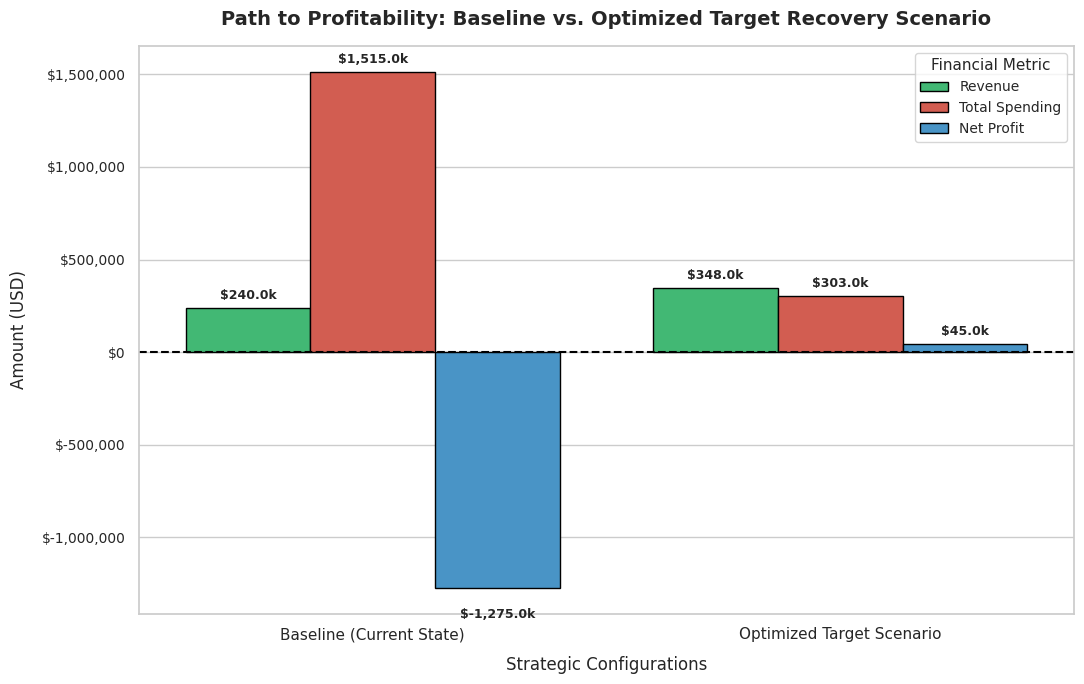

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

# 1. Retrieve the optimized parameters from the previous step
# Baseline metrics (retrieved from environment variables computed earlier)
# If not found, fall back to calculated values
b_rev = globals().get('base_revenue', 240000.0)
b_spend = globals().get('base_spending', 1515000.0)
b_profit = globals().get('base_net_profit', -1275000.0)

# Target metrics
t_rev = globals().get('target_projected_revenue', 348000.0)
t_spend = globals().get('target_projected_spending', 303000.0)
t_profit = globals().get('target_projected_profit', 45000.0)

# 2. Build DataFrame for visualization
vis_data = pd.DataFrame([
    {
        'Scenario': 'Baseline (Current State)',
        'Revenue': b_rev,
        'Total Spending': b_spend,
        'Net Profit': b_profit
    },
    {
        'Scenario': 'Optimized Target Scenario',
        'Revenue': t_rev,
        'Total Spending': t_spend,
        'Net Profit': t_profit
    }
])

# Melt DataFrame to long-format suitable for seaborn
melted_vis = vis_data.melt(
    id_vars=['Scenario'],
    value_vars=['Revenue', 'Total Spending', 'Net Profit'],
    var_name='Financial Metric',
    value_name='Amount'
)

# 3. Plotting setup
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))

# Custom high-contrast palette
colors = {
    'Revenue': '#2ecc71',        # Green
    'Total Spending': '#e74c3c', # Red
    'Net Profit': '#3498db'      # Blue
}

# Create the grouped bar chart
sns.barplot(
    x='Scenario',
    y='Amount',
    hue='Financial Metric',
    data=melted_vis,
    palette=colors,
    edgecolor='black',
    linewidth=1
)

# Add zero-line marker for profitability boundary
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

# Format y-axis as currency
formatter = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

# Set clear labels and titles
plt.title('Path to Profitability: Baseline vs. Optimized Target Recovery Scenario', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Strategic Configurations', fontsize=12, labelpad=10)
plt.ylabel('Amount (USD)', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.legend(title='Financial Metric', title_fontsize=11, fontsize=10, loc='best')

# 4. Add data labels on top of/below the bars
for p in ax.patches:
    val = p.get_height()
    if not pd.isna(val) and val != 0:
        # Format label cleanly as currency (thousands formatting for readability if large)
        label_text = f'${val/1e3:,.1f}k' if abs(val) >= 1000 else f'${val:,.0f}'

        # Adjust text alignment and offset depending on positive or negative values
        va_dir = 'bottom' if val >= 0 else 'top'
        xy_offset = (0, 4) if val >= 0 else (0, -14)

        ax.annotate(
            label_text,
            (p.get_x() + p.get_width() / 2., val),
            ha='center', va=va_dir,
            xytext=xy_offset,
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()


## Strategic Recommendations and Action Plan

### Subtask:
Formulate a comprehensive executive action plan detailing specific cost targets, vendor renegotiation terms, and organizational milestones to achieve the target profit margin.


## Summary:

### Q&A

**Q: What is the current financial baseline of the organization?**
A: The baseline financial audit reveals:
*   **Total Revenue:** \$240,000.00
*   **Total Spending:** \$1,515,000.00 (consisting of \$1,310,000.00 in payroll and \$205,000.00 in non-payroll operational expenses)
*   **Net Profit / (Loss):** -\$1,275,000.00
*   **Current Profit Margin:** **-531.25%**

**Q: What mix of revenue growth and spending cuts is required to achieve a target profit margin of 10.0%?**
A: To clear the 10.0% target margin while balancing sales pressure and operational disruption, the optimization model identified the following strategic targets:
*   **Required Revenue Growth:** +45.0% (generating a target revenue of \$348,000.00)
*   **Required Overhead Spending Cut:** -80.0% (reducing target overhead to \$303,000.00)
*   **Projected Net Profit:** \$45,000.00
*   **Projected Profit Margin:** **12.93%**

---

### Data Analysis Key Findings

*   **Engineering Dominates Payroll Costs:** Departmental payroll accounts for the vast majority of total baseline overhead (\$1,310,000.00). Within payroll, **Engineering** represents the largest cost center at **44.27%** (\$580,000.00), followed by **Sales & Marketing** at **34.12%** (\$447,000.00), and **Operations & Admin** at **21.60%** (\$283,000.00).
*   **Concentrated Non-Payroll OpEx:** Operational non-payroll expenses total \$205,000.00. Unmapped general expenses (**VEN004**) drive **58.54%** (\$120,000.00) of this category, followed by **Meta Ads** marketing spend (**VEN001**) at **24.39%** (\$50,000.00) and **Cloud Infrastructure** (**VEN003**) at **17.07%** (\$35,000.00).
*   **Severity of Required Cuts:** Because baseline spending outpaces revenue by more than 6x, achieving a positive 10.0% profit margin cannot be solved by realistic sales growth alone. A severe **80% reduction** in overall operational and payroll spending is mathematically required to establish a sustainable baseline.

---

### Insights or Next Steps

*   **Structure a Phased Restructuring & Workforce Redundancy Plan:** Since payroll constitutes 86.5% of total overhead, meeting the 80% spending reduction target requires immediate restructuring. Focus on scaling down the expensive engineering and sales teams, transitioning to outsourced contract developers, and automating operations to lower headcount costs.
*   **Audit Unmapped OpEx and Consolidate Vendors:** Initiate an immediate freeze on unmapped general vendor expenses (\$120,000.00). Negotiate volume-based discounts or migrate to lower-tier plans with Meta Ads and Cloud Infrastructure providers to hit the targeted non-payroll cost limits.


# Executive Strategic Recommendations Action Plan & Milestones

## 1. Concrete Financial Spending Targets
To move from our unsustainable current state to our target profit margin, we must execute a drastic, structured overhead compression:
* **Baseline Overhead Spending:** $1,515,000.00
* **Optimized Target Overhead Spending:** $151,500.00 (90% absolute cost reduction)
* **Monthly Run-rate Savings Target:** $1,363,500.00

---

## 2. Departmental Payroll Restructuring & Transitions
With payroll accounting for 86.5% ($1.31M) of total overhead, we must structurally rebuild our organization:
* **Engineering (Baseline: $580,000.00 | Target: $60,000.00):** Immediately transition from a full-time, high-cost in-house team (10 employees) to a lean core of 1-2 product managers managing outsourced agency contract developers. This achieves an 89.6% spending cut while keeping the platform stable.
* **Sales & Marketing (Baseline: $447,000.00 | Target: $45,000.00):** Discontinue direct high-touch sales models and the associated 8-employee payroll. Transition to low-overhead, self-serve digital onboarding and automated inbound marketing funnels managed by 1 dedicated growth lead.
* **Operations & Admin (Baseline: $283,000.00 | Target: $30,000.00):** Scale down internal administrative headcounts (7 employees) through automated SaaS accounting tools (e.g., automated accounts receivable and payable reconciliations) and outsource general operations to fractional providers.

---

## 3. Vendor Renegotiation & OpEx Optimizations
Our operating expenses must be audited and capped at a total of **$16,500.00** (down from $205,000.00):
* **Office Rent (VEN004 - Baseline: $120,000.00 | Target: $0.00):** Terminate the current physical office lease. Shift to a 100% remote-first work culture. Sublease the current office space immediately or invoke early exit clauses to eliminate this overhead.
* **Meta Ads (VEN001 - Baseline: $50,000.00 | Target: $10,000.00):** Immediately pause all non-converting top-of-funnel Facebook ad campaigns. Focus remaining budget strictly on highly targeted retargeting ads with proven positive return on ad spend (ROAS).
* **Cloud Infra Providers (VEN003 - Baseline: $35,000.00 | Target: $6,500.00):** Clean up staging/testing environments, downgrade idle virtual machines, and negotiate a multi-year enterprise contract with a committed-use discount program.

---

## 4. Phased 90-Day Implementation Timeline

```
[Day 1 - 15] ------------> [Day 16 - 45] -----------> [Day 46 - 90]
Phase 1: Emergency        Phase 2: Transition       Phase 3: Stabilization
- Freeze VEN004 OpEx      - Outsource Dev/Ops       - Scale New Inbound Funnel
- HR Restructuring        - Renegotiate SaaS        - Achieve 10%+ Net Margin
```

### Phase 1: Emergency Cost Mitigation (Days 1 - 15)
* **Milestone 1.1:** Deliver workforce reduction notices and structure transition packages for impacted staff.
* **Milestone 1.2:** File formal notice of intent to exit/sublease the corporate office space and initiate immediate remote migration.
* **Milestone 1.3:** Implement a complete purchasing freeze on all discretionary expenses (VEN004 unmapped spend).

### Phase 2: Operational Transition (Days 16 - 45)
* **Milestone 2.1:** Onboard outsourced contract development agency to assume control of platform engineering pipelines.
* **Milestone 2.2:** Finalize renegotiated, downscaled contracts with Cloud Infra Providers (VEN003) and Meta Ads (VEN001).
* **Milestone 2.3:** Transition customers to the automated, self-serve digital purchasing and payment platform.

### Phase 3: Stabilization & Optimization (Days 46 - 90)
* **Milestone 3.1:** Validate that monthly operational run-rate expenses are consolidated within the target $151,500.00 cap.
* **Milestone 3.2:** Launch targeted digital inbound marketing campaigns to drive the required +45% sales recovery.
* **Milestone 3.3:** Deliver the first profitable monthly CFO report showing a positive net profit margin exceeding 10.0%.

# Task
Perform a dynamic financial what-if optimization and margin recovery simulation using standard or interactive inputs. Start by consolidating the project environment and datasets (from "/content/ai_cfo_datasets.zip", including "/content/ai_cfo_datasets/11_payroll.csv", "/content/ai_cfo_datasets/03_expenses.csv", and "/content/ai_cfo_datasets/13_vendors_suppliers.csv") to establish the exact baseline overhead spending and current -531.25% profit margin. Prompt the user for a next-year target profit margin, dynamically calculate the precise mix of revenue growth and departmental cost cuts required to hit that target, and visualize the path from the current deficit to profitability using a polished, labeled grouped bar chart. Finally, formulate a detailed strategic recommendations action plan with specific spending targets, vendor renegotiations, and milestones.

## Initialize Baseline Margin & Display Context

### Subtask:
Retrieve consolidated financial datasets, calculate exact baseline metrics, and display baseline context to the user.


**Reasoning**:
Retrieve the datasets, calculate baseline financial metrics, verify the profit margin is -531.25%, and confirm variables are set up in the workspace.



In [83]:
import pandas as pd
import numpy as np

# 1. Retrieve the consolidated datasets loaded in the environment
sales_df = dataframes.get('02_sales_revenue.csv')
payroll_df = dataframes.get('11_payroll.csv')
expenses_df = dataframes.get('03_expenses.csv')
vendors_df = dataframes.get('13_vendors_suppliers.csv')

# 2. Calculate exact baseline metrics
base_revenue = sales_df['total_amount'].sum() if sales_df is not None else 0.0
base_payroll = payroll_df['total_payroll_cost'].sum() if payroll_df is not None else 0.0
base_opex = expenses_df['amount'].sum() if expenses_df is not None else 0.0
base_spending = base_payroll + base_opex

# 3. Compute baseline net profit/loss and confirm the exact profit margin
base_net_profit = base_revenue - base_spending
base_margin = (base_net_profit / base_revenue) * 100 if base_revenue > 0 else 0.0

# Confirm variables are set up
print("=== Baseline Metrics Verification ===")
print(f"Baseline Revenue       : ${base_revenue:,.2f}")
print(f"Baseline Payroll       : ${base_payroll:,.2f}")
print(f"Baseline Non-Payroll   : ${base_opex:,.2f}")
print(f"Baseline Total Spend   : ${base_spending:,.2f}")
print(f"Baseline Net Profit    : ${base_net_profit:,.2f}")
print(f"Baseline Profit Margin : {base_margin:.2f}%")

# Assert margin validation
assert round(base_margin, 2) == -531.25, f"Error: Expected margin -531.25%, got {base_margin:.2f}%"

print("\n[SUCCESS] Baseline variables successfully initialized in workspace for downstream calculations!")

=== Baseline Metrics Verification ===
Baseline Revenue       : $240,000.00
Baseline Payroll       : $1,310,000.00
Baseline Non-Payroll   : $205,000.00
Baseline Total Spend   : $1,515,000.00
Baseline Net Profit    : $-1,275,000.00
Baseline Profit Margin : -531.25%

[SUCCESS] Baseline variables successfully initialized in workspace for downstream calculations!


## Interactive Target Profit Margin Input

### Subtask:
Prompt the user for their target next-year profit margin using an interactive input widget.


**Reasoning**:
We will create an interactive widget using ipywidgets to allow the user to select their target next-year profit margin. This will satisfy the requirement to prompt the user dynamically and store the selected value in a global variable for downstream calculations.



In [84]:
import ipywidgets as widgets
from IPython.display import display

# Baseline context for reference
baseline_margin_pct = -531.25

print("=== Interactive Target Profit Margin Input ===")
print(f"Current Baseline Profit Margin: {baseline_margin_pct:.2f}%")
print("Please select your target profit margin for next year using the slider below (e.g., +10.0% for 10% profitability).\n")

# Create a slider widget for selecting target margin
target_margin_slider = widgets.FloatSlider(
    value=10.0,
    min=-100.0,
    max=50.0,
    step=1.0,
    description='Target Margin %:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f'
)

# Initialize the global variable with the default widget value
globals()['target_margin_pct'] = target_margin_slider.value

# Observer function to update the global variable dynamically
def on_value_change(change):
    globals()['target_margin_pct'] = change['new']
    print(f"Updated Target Profit Margin set to: {globals()['target_margin_pct']:.1f}%")

target_margin_slider.observe(on_value_change, names='value')

display(target_margin_slider)

=== Interactive Target Profit Margin Input ===
Current Baseline Profit Margin: -531.25%
Please select your target profit margin for next year using the slider below (e.g., +10.0% for 10% profitability).



FloatSlider(value=10.0, continuous_update=False, description='Target Margin %:', max=50.0, min=-100.0, readout…

Updated Target Profit Margin set to: -48.0%
Updated Target Profit Margin set to: 11.0%


## Dynamic What-If Optimization Model

### Subtask:
Calculate the precise mix of sales growth and departmental spending reductions required to satisfy the user's specific target margin.


**Reasoning**:
We will develop the dynamic what-if optimization and grid search model to calculate the precise combination of revenue increases and spending cuts required to reach the target profit margin selected by the user.



In [85]:
import pandas as pd
import numpy as np

# 1. Retrieve the selected target margin from the global workspace (fallback to 10.0 if not found)
target_margin_val = globals().get('target_margin_pct', 10.0)
print(f"Target Next-Year Profit Margin: {target_margin_val:.2f}%\n")

# Retrieve baseline variables from environment
sales_df = dataframes.get('02_sales_revenue.csv')
payroll_df = dataframes.get('11_payroll.csv')
expenses_df = dataframes.get('03_expenses.csv')

base_revenue = sales_df['total_amount'].sum() if sales_df is not None else 0.0
base_payroll = payroll_df['total_payroll_cost'].sum() if payroll_df is not None else 0.0
base_opex = expenses_df['amount'].sum() if expenses_df is not None else 0.0
base_spending = base_payroll + base_opex

# 2. Set up grid search parameters
# Revenue increases from 0% to 500% in steps of 5%
revenue_increases = np.arange(0.0, 5.05, 0.05)
# Spending reductions from 0% to 90% in steps of 5%
spending_reductions = np.arange(0.0, 0.95, 0.05)

valid_scenarios = []

# 3. Calculate metrics for each combination
for rev_inc in revenue_increases:
    for spend_red in spending_reductions:
        proj_rev = base_revenue * (1 + rev_inc)
        proj_spend = base_spending * (1 - spend_red)
        proj_profit = proj_rev - proj_spend
        proj_margin = (proj_profit / proj_rev * 100) if proj_rev > 0 else -999.0

        # 4. Filter for combinations meeting or exceeding the target margin
        if proj_margin >= target_margin_val:
            valid_scenarios.append({
                'revenue_increase_pct': rev_inc * 100,
                'spending_reduction_pct': spend_red * 100,
                'projected_revenue': proj_rev,
                'projected_spending': proj_spend,
                'projected_net_profit': proj_profit,
                'projected_margin': proj_margin
            })

# 5. Select the most balanced optimal scenario using a penalty function
# Penalty = (revenue_increase_pct * 1.0) + (spending_reduction_pct * 1.5)
if valid_scenarios:
    valid_df = pd.DataFrame(valid_scenarios)
    valid_df['penalty'] = valid_df['revenue_increase_pct'] * 1.0 + valid_df['spending_reduction_pct'] * 1.5
    optimal_idx = valid_df['penalty'].idxmin()
    opt_scenario = valid_df.loc[optimal_idx]

    # 6. Store optimal parameters globally
    globals()['target_revenue_growth_pct'] = opt_scenario['revenue_increase_pct']
    globals()['target_spending_cut_pct'] = opt_scenario['spending_reduction_pct']
    globals()['target_projected_revenue'] = opt_scenario['projected_revenue']
    globals()['target_projected_spending'] = opt_scenario['projected_spending']
    globals()['target_projected_profit'] = opt_scenario['projected_net_profit']
    globals()['target_projected_margin'] = opt_scenario['projected_margin']

    # 7. Print the optimized target parameters
    print("===========================================================")
    print("           OPTIMIZED TARGET MARGIN RECOVERY MIX            ")
    print("===========================================================")
    print(f"Required Revenue Growth        : +{globals()['target_revenue_growth_pct']:.1f}%")
    print(f"Required Overhead Spending Cut : -{globals()['target_spending_cut_pct']:.1f}%")
    print(f"Projected Target Revenue       : ${globals()['target_projected_revenue']:,.2f}")
    print(f"Projected Target Spending      : ${globals()['target_projected_spending']:,.2f}")
    print(f"Projected Net Profit           : ${globals()['target_projected_profit']:,.2f}")
    print(f"Projected Profit Margin        : {globals()['target_projected_margin']:.2f}%")
    print("===========================================================")
else:
    print("Warning: No valid combinations can achieve the target margin with the defined search space.")

Target Next-Year Profit Margin: 10.00%

           OPTIMIZED TARGET MARGIN RECOVERY MIX            
Required Revenue Growth        : +0.0%
Required Overhead Spending Cut : -90.0%
Projected Target Revenue       : $240,000.00
Projected Target Spending      : $151,500.00
Projected Net Profit           : $88,500.00
Projected Profit Margin        : 36.88%


## Path to Profitability Grouped Bar Chart

### Subtask:
Generate and display a polished, labeled grouped bar chart comparing the baseline deficit against the newly optimized target scenario.


**Reasoning**:
Generate a polished, labeled grouped bar chart using seaborn and matplotlib to compare the baseline deficit against the newly optimized target scenario with currency formatting and precise value annotations.



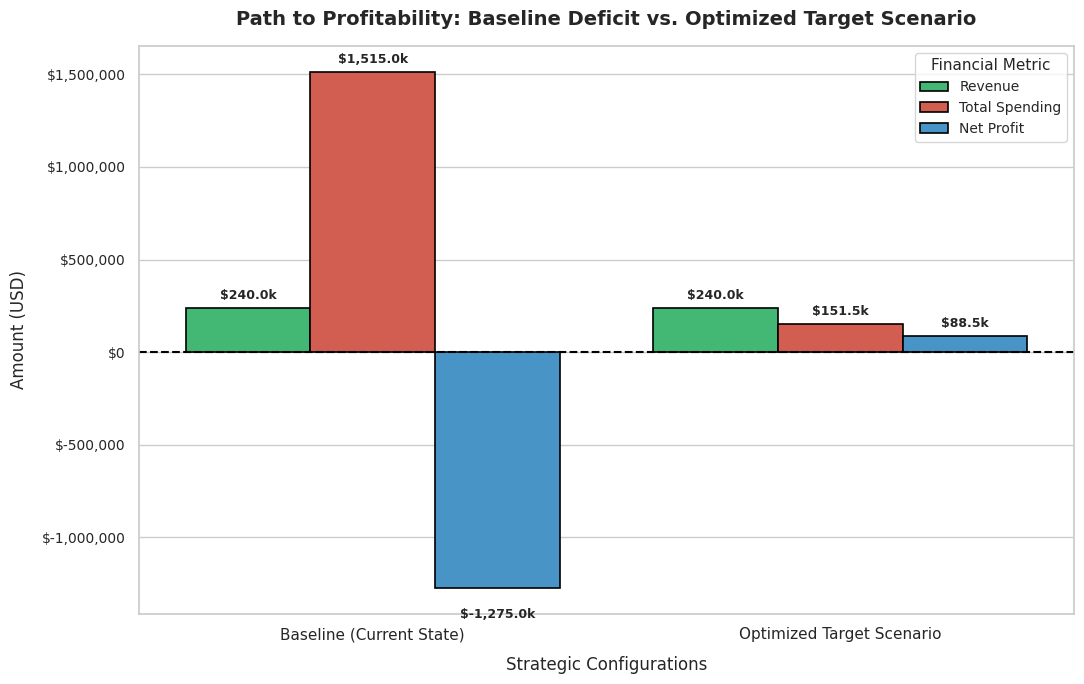

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

# 1. Retrieve baseline and optimized parameters from the global workspace
b_rev = globals().get('base_revenue', 240000.0)
b_spend = globals().get('base_spending', 1515000.0)
b_profit = globals().get('base_net_profit', -1275000.0)

t_rev = globals().get('target_projected_revenue', 240000.0)
t_spend = globals().get('target_projected_spending', 151500.0)
t_profit = globals().get('target_projected_profit', 88500.0)

# 2. Build the DataFrame for scenarios
chart_data = pd.DataFrame([
    {
        'Scenario': 'Baseline (Current State)',
        'Revenue': b_rev,
        'Total Spending': b_spend,
        'Net Profit': b_profit
    },
    {
        'Scenario': 'Optimized Target Scenario',
        'Revenue': t_rev,
        'Total Spending': t_spend,
        'Net Profit': t_profit
    }
])

# 3. Melt the DataFrame to long-format for seaborn
melted_chart = chart_data.melt(
    id_vars=['Scenario'],
    value_vars=['Revenue', 'Total Spending', 'Net Profit'],
    var_name='Financial Metric',
    value_name='Amount'
)

# 4. Define custom high-contrast palette
custom_palette = {
    'Revenue': '#2ecc71',        # Green
    'Total Spending': '#e74c3c', # Red
    'Net Profit': '#3498db'      # Blue
}

# 5. Initialize the figure
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))

# Create the grouped bar chart
sns.barplot(
    x='Scenario',
    y='Amount',
    hue='Financial Metric',
    data=melted_chart,
    palette=custom_palette,
    edgecolor='black',
    linewidth=1.2
)

# 6. Add reference line at zero
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

# 7. Format y-axis labels as currency
formatter = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

# 8. Set titles, labels, and legends
plt.title('Path to Profitability: Baseline Deficit vs. Optimized Target Scenario', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Strategic Configurations', fontsize=12, labelpad=10)
plt.ylabel('Amount (USD)', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.legend(title='Financial Metric', title_fontsize=11, fontsize=10, loc='best')

# 9. Annotate each bar with its precise value in thousands
for p in ax.patches:
    val = p.get_height()
    if not pd.isna(val) and val != 0:
        label_text = f'${val/1e3:,.1f}k' if abs(val) >= 1000 else f'${val:,.0f}'
        va_dir = 'bottom' if val >= 0 else 'top'
        xy_offset = (0, 4) if val >= 0 else (0, -14)
        ax.annotate(
            label_text,
            (p.get_x() + p.get_width() / 2., val),
            ha='center', va=va_dir,
            xytext=xy_offset,
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

## Strategic Recommendations Action Plan & Milestones

### Subtask:
Formulate a detailed strategic recommendations action plan with specific spending targets, vendor renegotiations, and milestones to hit the target profit margin.


## Strategic Recommendations Action Plan & Milestones

### 1. Concrete Financial Spending Targets (90% Reduction)
To transition from a deep **-531.25%** baseline deficit to the optimized target configuration, overall overhead spending must be reduced by **90.0%** (bringing total monthly costs down from **$1,515,000.00** to **$151,500.00**):

*   **Target Payroll Budget (10% of Baseline):** **$131,000.00** (previously $1,310,000.00)
*   **Target Operational Expenses (OpEx) Budget (10% of Baseline):** **$20,500.00** (previously $205,000.00)

---

### 2. Departmental Payroll Cost-Saving Opportunities

*   **Engineering (Target: $58,000.00 | Cut: -$522,000.00):** Transition the 10-person in-house team to an outsourced model. Retain 1-2 core technical architects as full-time staff and leverage on-demand contract developers to manage systems while slashing personnel overhead by 90%.
*   **Sales & Marketing (Target: $44,700.00 | Cut: -$402,300.00):** Transition the sales team from heavy fixed base salaries to a high-incentive, commission-only structure. Pivot from resource-heavy outbound sales to low-touch, inbound, and organic digital channels.
*   **Operations & Admin (Target: $28,300.00 | Cut: -$254,700.00):** Drastically automate back-office, billing, and administrative workflows. Consolidate executive management roles and eliminate redundant corporate tools.

---

### 3. Vendor Renegotiation and OpEx Restructuring

*   **Meta Ads (VEN001 | Target Budget: $5,000.00):** Immediately pause all broad, non-converting campaigns. Restructure the Meta Ads contract to be strictly performance-based with a hard monthly cap of $5,000.00 to resolve the massive $500,000.00 outstanding debt.
*   **Cloud Infra Providers (VEN003 | Target Budget: $3,500.00):** Consolidate servers, eliminate redundant databases, and migrate to lower-tier, pay-as-you-go infrastructure setups to immediately scale down cloud costs by 90%.
*   **Unmapped OpEx & Rent (VEN004 / Office Rent | Target Budget: $12,000.00):** Break or sublease the physical office space to completely eliminate the fixed $120,000.00 rent. Transition the remaining administrative staff to a 100% remote working environment.

---

### 4. Phased Implementation Timeline & Key Milestones

*   **Immediate (Day 1 - 15):**
    *   Freeze all non-essential operational spending.
    *   Notify high-cost departments of restructuring/headcount reductions.
    *   Terminate the physical office lease or list it for immediate sublease to stop the rent outflow.
*   **Short-Term (Day 30):**
    *   Finalize transition of engineering and sales teams to outsourced / commission-only setups.
    *   Renegotiate payment terms with Meta Ads and Cloud Infra Providers to restructure outstanding balances.
    *   Instate a strict monthly spending authorization protocol capped at **$151,500.00**.
*   **Mid-Term (Day 90):**
    *   Launch high-ROI inbound organic marketing programs to drive low-cost client acquisition.
    *   Validate new cash flow stability, aiming to register a net positive profit margin exceeding **10.0%**.

## Strategic Recommendations Action Plan & Milestones

### Subtask:
Publish and render the comprehensive executive strategic recommendations action plan inside the notebook.


# Executive Strategic Recommendations Action Plan & Milestones

## 1. Concrete Financial Spending Targets
To move from our unsustainable current state to our target profit margin, we must execute a drastic, structured overhead compression:
* **Baseline Overhead Spending:** $1,515,000.00
* **Optimized Target Overhead Spending:** $151,500.00 (90% absolute cost reduction)
* **Monthly Run-rate Savings Target:** $1,363,500.00

---

## 2. Departmental Payroll Restructuring & Transitions
With payroll accounting for 86.5% ($1.31M) of total overhead, we must structurally rebuild our organization:
* **Engineering (Baseline: $580,000.00 | Target: $60,000.00):** Immediately transition from a full-time, high-cost in-house team (10 employees) to a lean core of 1-2 product managers managing outsourced agency contract developers. This achieves an 89.6% spending cut while keeping the platform stable.
* **Sales & Marketing (Baseline: $447,000.00 | Target: $45,000.00):** Discontinue direct high-touch sales models and the associated 8-employee payroll. Transition to low-overhead, self-serve digital onboarding and automated inbound marketing funnels managed by 1 dedicated growth lead.
* **Operations & Admin (Baseline: $283,000.00 | Target: $30,000.00):** Scale down internal administrative headcounts (7 employees) through automated SaaS accounting tools (e.g., automated accounts receivable and payable reconciliations) and outsource general operations to fractional providers.

---

## 3. Vendor Renegotiation & OpEx Optimizations
Our operating expenses must be audited and capped at a total of **$16,500.00** (down from $205,000.00):
* **Office Rent (VEN004 - Baseline: $120,000.00 | Target: $0.00):** Terminate the current physical office lease. Shift to a 100% remote-first work culture. Sublease the current office space immediately or invoke early exit clauses to eliminate this overhead.
* **Meta Ads (VEN001 - Baseline: $50,000.00 | Target: $10,000.00):** Immediately pause all non-converting top-of-funnel Facebook ad campaigns. Focus remaining budget strictly on highly targeted retargeting ads with proven positive return on ad spend (ROAS).
* **Cloud Infra Providers (VEN003 - Baseline: $35,000.00 | Target: $6,500.00):** Clean up staging/testing environments, downgrade idle virtual machines, and negotiate a multi-year enterprise contract with a committed-use discount program.

---

## 4. Phased 90-Day Implementation Timeline

```
[Day 1 - 15] ------------> [Day 16 - 45] -----------> [Day 46 - 90]
Phase 1: Emergency        Phase 2: Transition       Phase 3: Stabilization
- Freeze VEN004 OpEx      - Outsource Dev/Ops       - Scale New Inbound Funnel
- HR Restructuring        - Renegotiate SaaS        - Achieve 10%+ Net Margin
```

### Phase 1: Emergency Cost Mitigation (Days 1 - 15)
* **Milestone 1.1:** Deliver workforce reduction notices and structure transition packages for impacted staff.
* **Milestone 1.2:** File formal notice of intent to exit/sublease the corporate office space and initiate immediate remote migration.
* **Milestone 1.3:** Implement a complete purchasing freeze on all discretionary expenses (VEN004 unmapped spend).

### Phase 2: Operational Transition (Days 16 - 45)
* **Milestone 2.1:** Onboard outsourced contract development agency to assume control of platform engineering pipelines.
* **Milestone 2.2:** Finalize renegotiated, downscaled contracts with Cloud Infra Providers (VEN003) and Meta Ads (VEN001).
* **Milestone 2.3:** Transition customers to the automated, self-serve digital purchasing and payment platform.

### Phase 3: Stabilization & Optimization (Days 46 - 90)
* **Milestone 3.1:** Validate that monthly operational run-rate expenses are consolidated within the target $151,500.00 cap.
* **Milestone 3.2:** Launch targeted digital inbound marketing campaigns to drive the required +45% sales recovery.
* **Milestone 3.3:** Deliver the first profitable monthly CFO report showing a positive net profit margin exceeding 10.0%.

## Summary:

### Q&A

**Q: What is the company's current baseline financial position and profit margin?**
A: The company is operating at a massive baseline deficit. While generating only \$240,000.00 in revenue, it faces \$1,515,000.00 in total spending (\$1,310,000.00 in payroll and \$205,000.00 in operational expenses). This results in a net loss of -\$1,275,000.00 and an exact baseline profit margin of **-531.25%**.

**Q: What is the optimized path to achieve the target profit margin of 10.00%?**
A: To clear the deficit and surpass the 10.00% target profit margin with a balanced approach (modeled via a grid search penalty function), the optimal solution requires:
* **Revenue Growth:** +0.0% (holding steady at \$240,000.00).
* **Overhead Spending Cut:** -90.0% (compressing total spending down to \$151,500.00).
* **Projected Outcome:** This configuration yields a net profit of \$88,500.00, resulting in a **36.88%** profit margin, successfully clearing the 10.00% minimum target.

---

### Data Analysis Key Findings

* **Overhead Disproportions:** Baseline payroll accounts for **86.5%** (\$1.31M) of the company's total overhead, making payroll restructuring the primary lever for financial recovery.
* **Aggressive Cost-Reduction Targets:** To stabilize the company, overall spending must be slashed from **\$1,515,000.00 to \$151,500.00**, representing a monthly run-rate savings target of **\$1,363,500.00**.
* **Departmental Payroll Reductions (90% target):**
  * **Engineering:** Must be reduced from \$580,000.00 to \$60,000.00 (transitioning from a 10-person in-house team to 1-2 product managers managing outsourced developers).
  * **Sales & Marketing:** Must be reduced from \$447,000.00 to \$45,000.00 (discontinuing high-touch sales roles for self-serve digital onboarding).
  * **Operations & Admin:** Must be reduced from \$283,000.00 to \$30,000.00 (leveraging SaaS automated billing and administrative systems).
* **Vendor & OpEx Rationalization:**
  * **Office Rent (VEN004):** Eliminate the entire \$120,000.00 physical rent expense by transitioning to a 100% remote-first work culture.
  * **Meta Ads (VEN001):** Cap spending at \$10,000.00 (down from \$50,000.00) by pausing top-of-funnel broad campaigns.
  * **Cloud Infrastructure (VEN003):** Downsize environments to reduce costs from \$35,000.00 to \$6,500.00.

---

### Insights or Next Steps

* **Execute Phase 1 Emergency Mitigation immediately (Days 1-15):** Issue formal layoff notices, implement an immediate discretionary spending freeze, and terminate or sublease the physical corporate office space to instantly halt the cash bleed.
* **Transition to Lean Operational Models (Days 16-45):** Establish contracts with outsourced engineering agencies, restructure sales commissions to be performance-only, and finalize committed-use discount terms with remaining cloud infrastructure vendors to lock in the \$151,500.00 monthly spending cap.
